In [1]:
# Set workspace
import sys
import os
workspace_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if workspace_root not in sys.path:
    sys.path.insert(0, workspace_root)

# Libraries

In [2]:
# Libraries
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import gpxpy

In [3]:
# Other helpers

from helper_functions.gpx_to_tabular import (
    gpx_to_tabular,
)

from helper_functions.sector_data_cleanup import (
    clean_runner_race_sector_data,
    apply_rest_only_checkpoint_correction,
    add_sector_distance_features,
    build_sector_boundaries,
    build_course_sector_elevation_aggregation,
    add_sector_elevation_features,
)

from helper_functions.univariate_feature_analysis import (
    univariate_numeric_linear_analysis
)

---
# Get data

In [4]:
# Config
years = [2022, 2023, 2024, 2025]

Load data

In [5]:
# Get local race results data for UTMB

# Dictionary | key = year
utmb_race_results_df_dict = dict()
for year in years:

    utmb_year_race_results_df = pd.read_parquet(
        os.path.join("..", "utmb_under_27h/data", f"utmb_{year}_race_results.parquet")
    )
    utmb_year_race_results_df = utmb_year_race_results_df.assign(year=year)

    print(f"Data for year {year} fetched and loaded successfully")
    utmb_race_results_df_dict[year] = utmb_year_race_results_df

# Single dataframe with all years
utmb_race_results_df = pd.concat(
    utmb_race_results_df_dict.values(),
    ignore_index=True
).reset_index(drop=True)

Data for year 2022 fetched and loaded successfully
Data for year 2023 fetched and loaded successfully
Data for year 2024 fetched and loaded successfully
Data for year 2025 fetched and loaded successfully


In [6]:
# Get sector data for UTMB

# Dictionary | key = year
utmb_sector_data_dict = dict()
for year in years:

    with open(os.path.join(f"data", f"utmb_{year}_sector_data.pkl"), "rb") as f:
        utmb_year_sector_data_dict = pickle.load(f)

    print(f"Data for year {year} fetched and loaded successfully")
    utmb_sector_data_dict[year] = utmb_year_sector_data_dict

Data for year 2022 fetched and loaded successfully
Data for year 2023 fetched and loaded successfully
Data for year 2024 fetched and loaded successfully
Data for year 2025 fetched and loaded successfully


In [7]:
# UTMB GPX - We use the 2025 GPX file as the reference course for all years. This assumes the course geometry is close enough across years for descriptive elevation/distance features.
gpx_file_path = "utmb_2025_course.gpx"
with open(gpx_file_path, "r") as f:
    utmb_gpx = gpxpy.parse(f)

utmb_course_df = gpx_to_tabular(utmb_gpx)

Connect Race data & Sector data

In [8]:
# Connect Race data & Sector data & Save locally (/Load)

CONNECT_RACE_SECTOR_DATA = False
SAVE_RACE_SECTOR_DATA = False

runner_race_sector_data_dict = dict()
runner_race_sector_data_year_dfs = []

# Connect
if CONNECT_RACE_SECTOR_DATA:
    for year in years:
        print(" - Connecting year {} ...".format(year))

        # Year-level race results table
        utmb_race_results_year_df = (
            utmb_race_results_df_dict[year]
            .set_index("runner_bib_number")
        )

        # Year-level sector data dict: {bib_number -> sector dataframe}
        utmb_sector_data_year_dict = utmb_sector_data_dict[year]

        # Collect runner-level sector data for this year
        runner_race_sector_data_year_list = []
        for bib_number, utmb_sector_data_year_bib_df in utmb_sector_data_year_dict.items():

            if bib_number not in utmb_race_results_year_df.index:
                continue

            utmb_race_results_year_bib_series = utmb_race_results_year_df.loc[bib_number]

            utmb_sector_data_year_bib_df = (
                utmb_sector_data_year_bib_df
                .assign(**utmb_race_results_year_bib_series.to_dict())
            )

            # Store runner-level dataframe in the dict and in the year list
            runner_race_sector_data_dict[(year, bib_number)] = utmb_sector_data_year_bib_df
            runner_race_sector_data_year_list.append(utmb_sector_data_year_bib_df)

        # Drop all-NA columns once, after the year loop
        runner_race_sector_data_year_list = [
            df.dropna(axis=1, how="all")
            for df in runner_race_sector_data_year_list
            if df is not None and not df.empty
        ]

        # Combine all runners for the year into one dataframe
        if runner_race_sector_data_year_list:
            runner_race_sector_data_year_df = pd.concat(
                runner_race_sector_data_year_list,
                ignore_index = True,
            )
            runner_race_sector_data_year_dfs.append(runner_race_sector_data_year_df)

            # Save
            if SAVE_RACE_SECTOR_DATA:
                save_path = os.path.join(
                    "..",
                    "pacing_strategy",
                    "data",
                    f"runner_race_sector_data_{year}.parquet",
                )
                runner_race_sector_data_year_df.to_parquet(save_path, index = False)
                print(" - Saved year {} to {}".format(year, save_path))

# Load
if not CONNECT_RACE_SECTOR_DATA:
    for year in years:
        load_path = os.path.join("..", "pacing_strategy", "data", f"runner_race_sector_data_{year}.parquet")
        runner_race_sector_data_year_df = pd.read_parquet(load_path)

        runner_race_sector_data_year_dfs.append(runner_race_sector_data_year_df)
        print(" - Loaded year {} from {}".format(year, load_path))

# Combine all years
runner_race_sector_data_df = pd.concat(
    runner_race_sector_data_year_dfs,
    ignore_index = True,
)

 - Loaded year 2022 from ..\pacing_strategy\data\runner_race_sector_data_2022.parquet
 - Loaded year 2023 from ..\pacing_strategy\data\runner_race_sector_data_2023.parquet
 - Loaded year 2024 from ..\pacing_strategy\data\runner_race_sector_data_2024.parquet
 - Loaded year 2025 from ..\pacing_strategy\data\runner_race_sector_data_2025.parquet


--- 
# About data & Data work

In [9]:
# Assign Runner ID -  Runner/Race/Year unique identifier
runner_race_sector_data_df = runner_race_sector_data_df.assign(
    runner_id = lambda x: x.groupby([
        "runner_bib_number",
        "race_id",
        "year",
    ]).ngroup() + 1
)

About data

In [108]:
# About data
print("About data:")
print("-------------------------------------")
print("Race IDs: {}".format(runner_race_sector_data_df["race_id"].unique()))
print("Race names: {}".format(runner_race_sector_data_df["race_name"].unique()))
print("Years: {}".format(runner_race_sector_data_df["year"].unique()))
print("Number of unique runners: {:,}".format(runner_race_sector_data_df["runner_url"].nunique()))
print("Number of unique Runner/Race/Year combinations: {:,}".format(runner_race_sector_data_df["runner_id"].nunique()))

print("\nRunners per year:")
for year, n_runners in runner_race_sector_data_df.groupby("year")["runner_id"].nunique().items():
    print(" - year {} - runners {:,}".format(year, n_runners))

About data:
-------------------------------------
Race IDs: ['utmb']
Race names: ['UTMB®']
Years: [2022 2023 2024 2025]
Number of unique runners: 9,528
Number of unique Runner/Race/Year combinations: 10,563

Runners per year:
 - year 2022 - runners 2,627
 - year 2023 - runners 2,687
 - year 2024 - runners 2,760
 - year 2025 - runners 2,489


In [110]:
# About finishers / DNFs
runner_finisher_summary_df = (
    runner_race_sector_data_df
    .drop_duplicates(subset = ["race_id", "year", "runner_id"])
    .assign(
        runner_status = lambda df: np.where(
            df["runner_is_finisher"],
            "Finisher",
            "DNF",
        )
    )
)

print("About finishers:")
print("-------------------------------------")
print("Number of finishers: {:,}".format(runner_finisher_summary_df["runner_is_finisher"].sum()))
print("Number of DNFs: {:,}".format((~runner_finisher_summary_df["runner_is_finisher"]).sum()))
print("Finisher share: {:.1f}%".format(runner_finisher_summary_df["runner_is_finisher"].mean() * 100))

print("\nFinishers / DNFs per year:")
for year, df_year in runner_finisher_summary_df.groupby("year"):

    number_of_runners = df_year["runner_id"].nunique()
    number_of_finishers = df_year["runner_is_finisher"].sum()
    number_of_dnfs = (~df_year["runner_is_finisher"]).sum()
    finisher_share = df_year["runner_is_finisher"].mean() * 100

    print(" - year {} - runners {:,}, finishers {:,}, DNFs {:,}, finisher share {:.1f}%".format(
        year,
        number_of_runners,
        number_of_finishers,
        number_of_dnfs,
        finisher_share,
        )
    )

About finishers:
-------------------------------------
Number of finishers: 6,971
Number of DNFs: 3,592
Finisher share: 66.0%

Finishers / DNFs per year:
 - year 2022 - runners 2,627, finishers 1,789, DNFs 838, finisher share 68.1%
 - year 2023 - runners 2,687, finishers 1,757, DNFs 930, finisher share 65.4%
 - year 2024 - runners 2,760, finishers 1,760, DNFs 1,000, finisher share 63.8%
 - year 2025 - runners 2,489, finishers 1,665, DNFs 824, finisher share 66.9%


In [11]:
# About Sectors
print("About sectors:")
print("-------------------------------------")
print("Number of sector checpoints: {:,}".format(runner_race_sector_data_df["sector_checkpoint_id"].nunique()))
print("Sector checkpoint IDs: {}".format(runner_race_sector_data_df["sector_checkpoint_id"].unique().tolist()))

print("Do all races/years have the same number of sectors? {}".format(
    runner_race_sector_data_df.groupby(["race_id", "year"])["sector_checkpoint_id"].nunique().nunique() == 1
))

sector_sets = runner_race_sector_data_df.groupby(["race_id", "year"])["sector_checkpoint_id"].apply(lambda s: frozenset(s.unique()))
print("Do all races/years have the same sector IDs? {}".format(
    sector_sets.nunique() == 1
))

expected_sector_count = runner_race_sector_data_df.groupby(["race_id", "year"])["sector_checkpoint_id"].nunique()
runner_sector_counts = runner_race_sector_data_df.groupby(["race_id", "year", "runner_bib_number"])["sector_checkpoint_id"].nunique()
print("Do all runners have all of the sectors? {}".format(
    runner_sector_counts.groupby(["race_id", "year"]).min().eq(expected_sector_count).all()
))

About sectors:
-------------------------------------
Number of sector checpoints: 31
Sector checkpoint IDs: [0, 2, 3, 4, 5, 6, 7, 8, 11, 12, 13, 14, 15, 18, 20, 22, 24, 27, 29, 30, 31, 33, 34, 35, 43, 44, 143, 19, 144, 9, 23]
Do all races/years have the same number of sectors? False
Do all races/years have the same sector IDs? False


Do all runners have all of the sectors? True


In [12]:
# About Sectors - Deep
sector_data_summary = (
    runner_race_sector_data_df
    .groupby("year")
    .aggregate(
        number_of_sectors = ("sector_checkpoint_id", "nunique"),
        sector_checkpoint_ids = ("sector_checkpoint_id", lambda x: [int(value) for value in sorted(x.unique())]),
    )
    .reset_index()
)

for _, row in sector_data_summary.iterrows():
    print(f"\nYear: {row['year']}")
    print("----------------------------------------")
    print(f"Number of sectors: {row['number_of_sectors']}")
    print(f"Sector checkpoint IDs: {row['sector_checkpoint_ids']}")

# Common and Unique sectors by years
sector_ids_by_year = (
    runner_race_sector_data_df
    .assign(year = lambda df: df["year"].astype(int))
    .groupby("year")["sector_checkpoint_id"]
    .apply(lambda s: set(int(x) for x in s.unique()))
)

all_sector_ids = set.union(*sector_ids_by_year.tolist())
common_sector_ids = set.intersection(*sector_ids_by_year.tolist())
not_common_sector_ids = all_sector_ids - common_sector_ids

all_years = sorted(sector_data_summary["year"].astype(int).unique().tolist())
sector_years = (
    runner_race_sector_data_df
    .groupby("sector_checkpoint_id")["year"]
    .apply(lambda s: sorted(s.astype(int).unique().tolist()))
)

print("\nAbout common sectors:")
print("----------------------------------------")
print("Number of common sector IDs: {} ({:.0f}%)".format(len(common_sector_ids), len(common_sector_ids) / len(all_sector_ids) * 100))
print("Number of not common sector IDs: {} ({:.0f}%)".format(len(not_common_sector_ids), len(not_common_sector_ids) / len(all_sector_ids) * 100))
print("Common sector IDs across all years: {}".format(sorted(common_sector_ids)))
print("Sector IDs not common to all years, with years present:")
for sector_id in sorted(not_common_sector_ids):
    missing_years = sorted(set(all_years) - set(sector_years[sector_id]))
    print(" - {} -> missing years: {}".format(sector_id, missing_years))


Year: 2022
----------------------------------------
Number of sectors: 27
Sector checkpoint IDs: [0, 2, 3, 4, 5, 6, 7, 8, 11, 12, 13, 14, 15, 18, 20, 22, 24, 27, 29, 30, 31, 33, 34, 35, 43, 44, 143]

Year: 2023
----------------------------------------
Number of sectors: 26
Sector checkpoint IDs: [0, 2, 3, 4, 5, 6, 7, 8, 11, 12, 13, 14, 15, 18, 19, 20, 22, 24, 27, 30, 31, 33, 34, 35, 44, 144]

Year: 2024
----------------------------------------
Number of sectors: 28
Sector checkpoint IDs: [0, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 18, 19, 20, 22, 23, 24, 27, 30, 31, 33, 34, 35, 44, 144]

Year: 2025
----------------------------------------
Number of sectors: 26
Sector checkpoint IDs: [0, 2, 3, 4, 6, 7, 8, 9, 11, 12, 13, 14, 15, 18, 19, 20, 22, 24, 27, 30, 31, 33, 34, 35, 44, 144]



About common sectors:
----------------------------------------
Number of common sector IDs: 23 (74%)
Number of not common sector IDs: 8 (26%)
Common sector IDs across all years: [0, 2, 3, 4, 6, 7, 8, 11, 12, 13, 14, 15, 18, 20, 22, 24, 27, 30, 31, 33, 34, 35, 44]
Sector IDs not common to all years, with years present:
 - 5 -> missing years: [2025]
 - 9 -> missing years: [2022, 2023]
 - 19 -> missing years: [2022]
 - 23 -> missing years: [2022, 2023, 2025]
 - 29 -> missing years: [2023, 2024, 2025]
 - 43 -> missing years: [2023, 2024, 2025]
 - 143 -> missing years: [2023, 2024, 2025]
 - 144 -> missing years: [2022]


Work on sector data - cleanup and new features
- Add some additional sector description columns
- Correct rest only sectors
- Sector absolute and relative distance
- Calculate elevation features with help of GPX data

In [13]:
# Raw Sector data display 
sector_cols = runner_race_sector_data_df.columns[
    runner_race_sector_data_df.columns.str.contains("sector")
]

display(
    runner_race_sector_data_df
    .loc[:, ["runner_id"] + sector_cols.tolist()]
    .head(30)
)

,runner_id,sector_checkpoint_id,sector_arrival_time,sector_departure_time,sector_rest_time_seconds,sector_speed_kmh,sector_pace_min_per_km,sector_time_seconds,sector_time,sector_race_time_at_checkpoint,sector_checkpoint_rank,sector_checkpoint_rank_change,sector_rest_time,sector_predicted_time
0,1,0,None,2022-08-26T15:59:57.000Z,NaN,NaN,NaN,NaN,None,None,NaN,NaN,None,NaN
1,1,2,2022-08-26T17:08:12.160Z,2022-08-26T17:08:12.160Z,NaN,11.70,5.13,4095.16,1:08:15,1:08:15,2.0,NaN,None,NaN
2,1,3,2022-08-26T17:46:37.540Z,2022-08-26T17:46:37.540Z,NaN,13.07,4.59,6400.54,0:38:25,1:46:41,3.0,1.0,None,NaN
3,1,4,2022-08-26T18:37:17.930Z,2022-08-26T18:37:17.930Z,NaN,11.43,5.25,9440.93,0:50:40,2:37:21,2.0,-1.0,None,NaN
4,1,5,2022-08-26T19:30:25.280Z,2022-08-26T19:30:25.280Z,NaN,9.41,6.38,12628.28,0:53:07,3:30:28,1.0,-1.0,None,NaN
5,1,6,None,None,NaN,NaN,NaN,NaN,None,None,NaN,NaN,None,NaN
6,1,7,2022-08-26T20:52:38.090Z,2022-08-26T20:55:24.650Z,166.56,7.75,7.74,17561.09,1:22:13,4:52:41,2.0,1.0,0:02:47,NaN
7,1,8,2022-08-26T22:14:01.000Z,2022-08-26T22:14:01.000Z,NaN,8.12,7.39,22444.00,1:18:36,6:14:04,3.0,1.0,None,NaN
8,1,11,2022-08-26T22:59:53.820Z,2022-08-26T22:59:53.820Z,NaN,9.35,6.42,25196.82,0:45:53,6:59:57,2.0,-1.0,None,NaN
9,1,12,2022-08-26T23:34:24.000Z,2022-08-26T23:34:24.000Z,NaN,6.94,8.65,27267.00,0:34:30,7:34:27,2.0,0.0,None,NaN


In [14]:
# Work on sector data - pipe with helper_functions/sector_data_cleanup.py

runner_race_sector_data_df = (
    runner_race_sector_data_df
    .pipe(clean_runner_race_sector_data) # Add some additional sector description columns
    .pipe(apply_rest_only_checkpoint_correction) # Correct rest only sectors
    .pipe(add_sector_distance_features) # Sector absolute and relative distance
)

# - Build sector boundaries - for connecting with GPX data
# - Aggregate GPX course features by sector
# - Add elevation features to sector data and calculate additional elevation sector features
sector_boundaries_df = build_sector_boundaries(
    sector_df = runner_race_sector_data_df
)
course_sector_elevation_df = build_course_sector_elevation_aggregation(
    utmb_course_df = utmb_course_df,
    sector_boundaries_df = sector_boundaries_df
)
runner_race_sector_data_df = add_sector_elevation_features(
    sector_df = runner_race_sector_data_df,
    course_sector_agg_df = course_sector_elevation_df,
)

In [15]:
# Sector IDs: 1-max, not "random" values (Race/Year specific)
runner_race_sector_data_df = (
    runner_race_sector_data_df
    .assign(
        sector_number = lambda x: x
        .groupby(["race_id", "year"])["sector_checkpoint_id"]
        .rank(method="dense", ascending=True)
        .astype(int)
    )
)

# Sanity check
check_df = (
    runner_race_sector_data_df[["race_id", "year", "sector_checkpoint_id", "sector_number"]]
    .drop_duplicates()
)

assert (
    check_df.groupby(["race_id", "year"])["sector_checkpoint_id"].nunique()
    == check_df.groupby(["race_id", "year"])["sector_number"].nunique()
).all(), "Sector checkpoint mapping is not 1-to-1 within at least one race/year."

assert (
    check_df.groupby(["race_id", "year"])["sector_number"].min() == 1
).all(), "Sector checkpoint numbering does not start at 1 for at least one race/year."

Analysis data - Finishers

In [16]:
# Split finishers & DNFs
runner_race_sector_data_dnf_df = runner_race_sector_data_df.loc[
    ~runner_race_sector_data_df["runner_is_finisher"]
    ].reset_index(drop=True).copy()

runner_race_sector_data_finisher_df = runner_race_sector_data_df.loc[
    runner_race_sector_data_df["runner_is_finisher"]
    ].reset_index(drop=True).copy()

In [17]:
# Pacing analysis data = finishers
pacing_analysis_df = runner_race_sector_data_finisher_df.copy()

---
# Race time normalization

- Raw race times are not directly comparable because runners have different pre-race ability, and different years may have different conditions.
- We estimate each runner's expected race time from pre-race ability and race year.
- Normalization lets us compare runners more fairly.
- We can estimate whether the runner performed better or worse than expected.

Estimate expected runner race time (Linear model)
- Based on UTMB index & Race year
- T ~ UTMB_index + Race_year + UTMB_index:Race_year

In [18]:
# Race time normalization data - one row per runner/year
df_race_time_normalization = (
    pacing_analysis_df
    .drop_duplicates(subset=["runner_id"])
    .assign(
        runner_overall_index_centered = lambda df: (
            df["runner_overall_index"] - df["runner_overall_index"].mean()
        )
    )
    [["runner_id", "runner_race_time_hours", "runner_overall_index_centered", "year"]]
    
    .dropna(how="any")
    .reset_index(drop=True)
    .copy()
)

In [19]:
# Linear model - Fit & Predict

# Fit 
model_race_time_normalization = smf.ols(
    formula = "runner_race_time_hours ~ runner_overall_index_centered * C(year)",
    data = df_race_time_normalization,
)
fit_race_time_normalization = model_race_time_normalization.fit()

# Predict & store predictions
y_pred_race_time_normalization = fit_race_time_normalization.predict(df_race_time_normalization)
df_race_time_normalization["runner_race_time_hours_pred"] = y_pred_race_time_normalization

In [20]:
# Coefficients
coef_race_time_normalization_df = (
    pd.DataFrame({
        "coef": fit_race_time_normalization.params,
        "std_err": fit_race_time_normalization.bse,
        "p_value": fit_race_time_normalization.pvalues,
        "ci_lower": fit_race_time_normalization.conf_int()[0],
        "ci_upper": fit_race_time_normalization.conf_int()[1],
    })
    .reset_index(names="term")
)

coef_race_time_normalization_df

,term,coef,std_err,p_value,ci_lower,ci_upper
0,Intercept,39.024406,0.079678,0.000000,38.868213,39.180600
1,C(year)[T.2023],0.190230,0.112074,0.089674,-0.029470,0.409930
2,C(year)[T.2024],0.137372,0.111856,0.219446,-0.081900,0.356644
3,C(year)[T.2025],-0.074187,0.113789,0.514444,-0.297249,0.148875
4,runner_overall_index_centered,-0.048735,0.000814,0.000000,-0.050331,-0.047139
5,runner_overall_index_centered:C(year)[T.2023],-0.002351,0.001158,0.042417,-0.004621,-0.000080
6,runner_overall_index_centered:C(year)[T.2024],-0.004656,0.001162,0.000062,-0.006934,-0.002379
7,runner_overall_index_centered:C(year)[T.2025],-0.005087,0.001169,0.000014,-0.007378,-0.002796


In [21]:
# Calculate absolute race time residual: Expected - Actual
df_race_time_normalization = (
    df_race_time_normalization
    .assign(
        runner_race_time_hours_residual_abs = lambda df: (
            df["runner_race_time_hours_pred"] - df["runner_race_time_hours"]
        )
    )
)

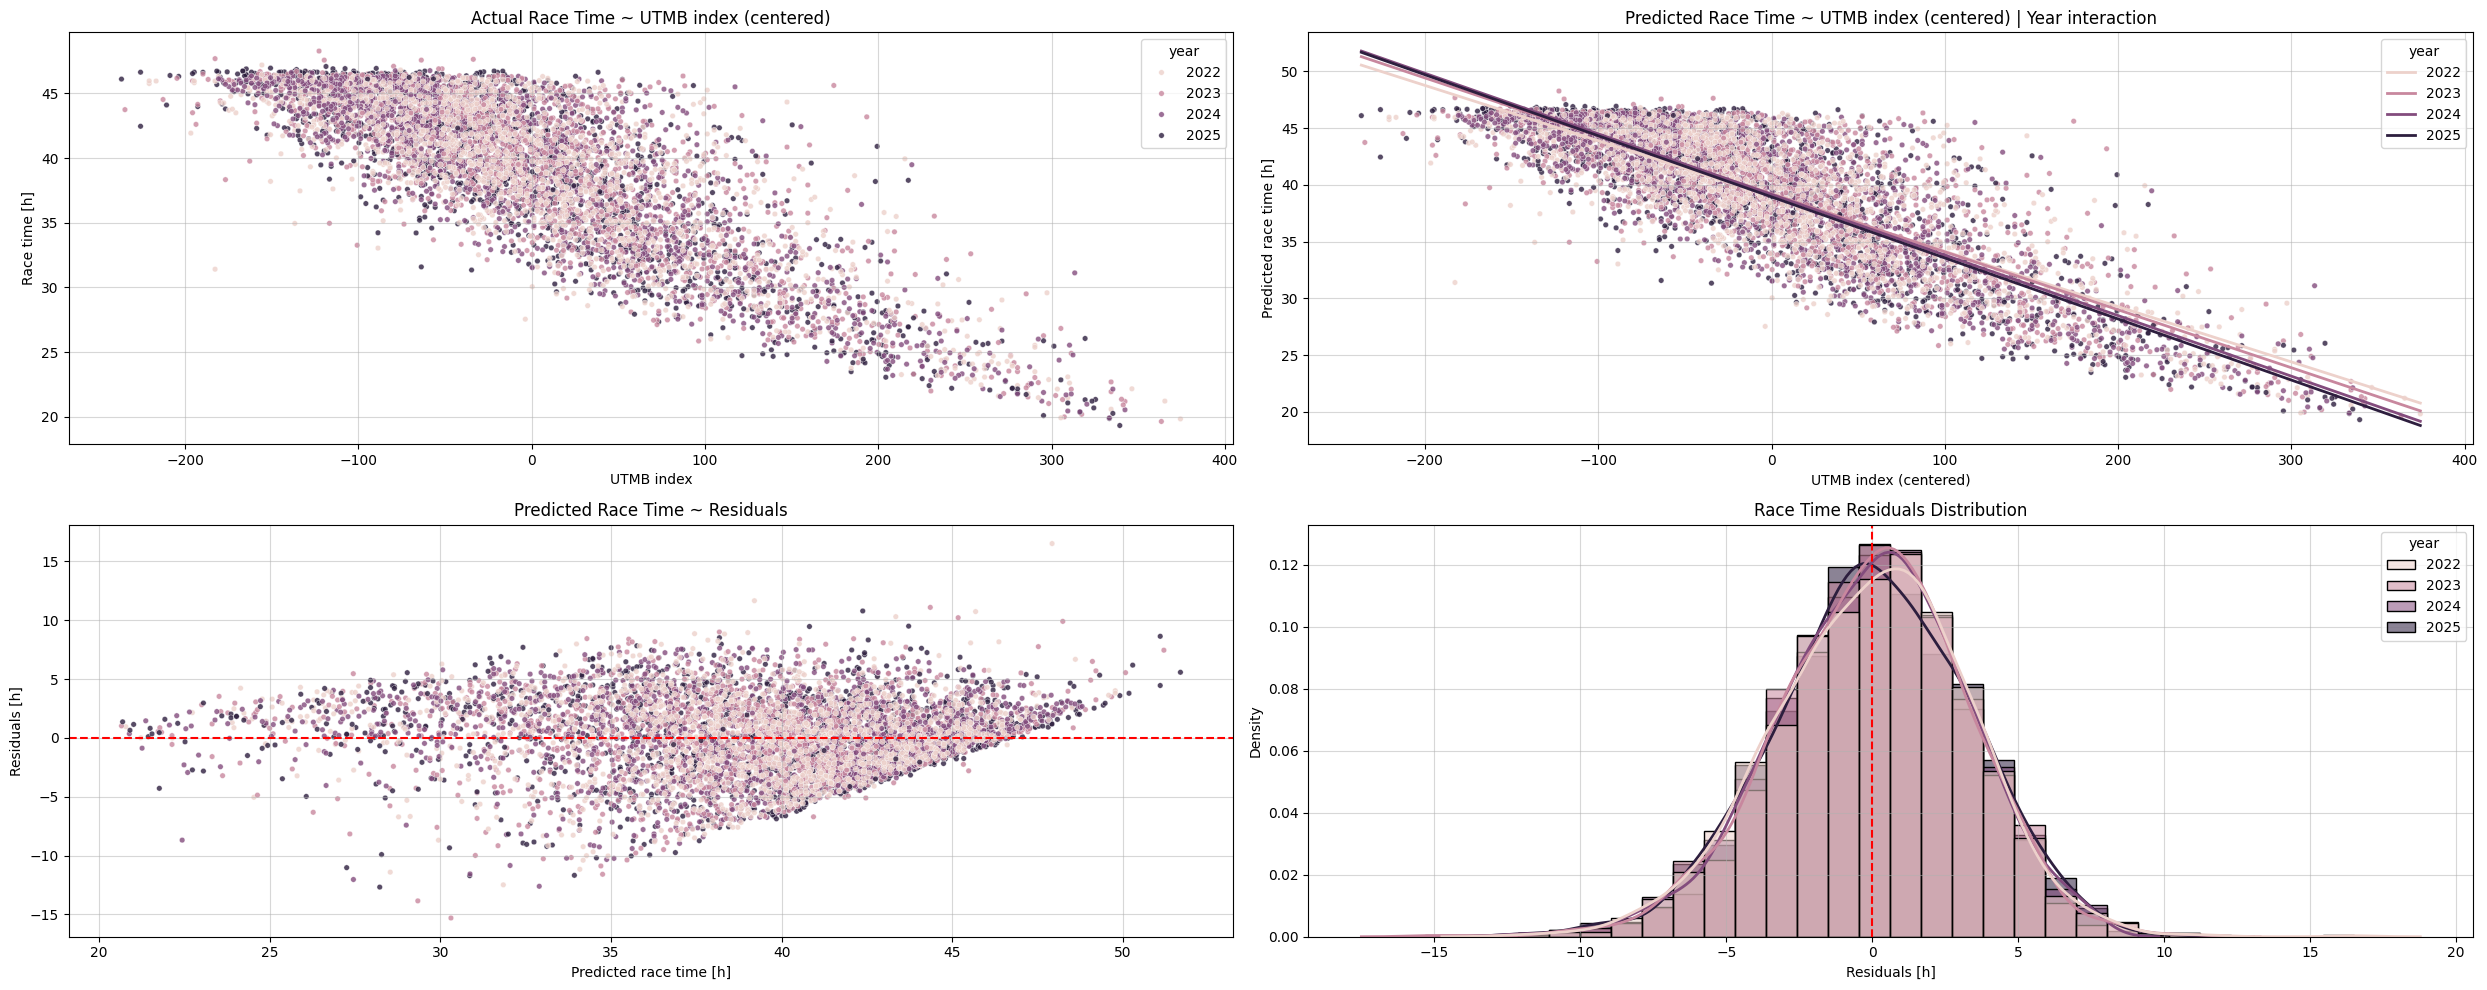

In [22]:
# Model diagnostic

fig, ax = plt.subplots(2, 2, figsize = (25, 10))

# Prediction grid for model lines
utmb_index_grid = np.linspace(
    df_race_time_normalization["runner_overall_index_centered"].min(),
    df_race_time_normalization["runner_overall_index_centered"].max(),
    100,
)

pred_grid_df = pd.concat(
    [
        pd.DataFrame({
            "runner_overall_index_centered": utmb_index_grid,
            "year": year,
        })
        for year in sorted(df_race_time_normalization["year"].unique())
    ],
    ignore_index = True,
)

pred_grid_df = pred_grid_df.assign(
    runner_race_time_hours_pred = fit_race_time_normalization.predict(pred_grid_df)
)

# Actual Race Time ~ UTMB index
ax[0,0].set_title("Actual Race Time ~ UTMB index (centered)")
sns.scatterplot(
    data = df_race_time_normalization, x = "runner_overall_index_centered", y = "runner_race_time_hours",
    hue = "year", s = 16, alpha = 0.8, ax = ax[0,0],
)
ax[0,0].set_xlabel("UTMB index")
ax[0,0].set_ylabel("Race time [h]")

# Model prediction lines by year
ax[0,1].set_title("Predicted Race Time ~ UTMB index (centered) | Year interaction")
sns.scatterplot(
    data = df_race_time_normalization, x = "runner_overall_index_centered", y = "runner_race_time_hours",
    hue = "year", s = 16, alpha = 0.8, ax = ax[0,1], legend = False,
)
sns.lineplot(
    data = pred_grid_df, x = "runner_overall_index_centered", y = "runner_race_time_hours_pred",
    hue = "year", linewidth = 2, ax = ax[0,1],
)
ax[0,1].set_xlabel("UTMB index (centered)")
ax[0,1].set_ylabel("Predicted race time [h]")

# Predicted values vs. residuals
ax[1,0].set_title("Predicted Race Time ~ Residuals")
sns.scatterplot(
    data = df_race_time_normalization, x = "runner_race_time_hours_pred", y = "runner_race_time_hours_residual_abs",
    hue = "year", s = 16, alpha = 0.8, ax = ax[1,0], legend = False,
)
ax[1,0].axhline(0, color = "red", linestyle = "--")
ax[1,0].set_xlabel("Predicted race time [h]")
ax[1,0].set_ylabel("Residuals [h]")

# Residuals distribution
ax[1,1].set_title("Race Time Residuals Distribution")
sns.histplot(
    data = df_race_time_normalization, x = "runner_race_time_hours_residual_abs",
    hue = "year", bins = 30, stat = "density", common_norm = False, alpha = 0.55,
    ax = ax[1,1],
)
sns.kdeplot(
    data = df_race_time_normalization, x = "runner_race_time_hours_residual_abs",
    hue = "year", common_norm = False, linewidth = 2, ax = ax[1,1],
    legend = False,
)
ax[1,1].axvline(0, color = "red", linestyle = "--")
ax[1,1].set_xlabel("Residuals [h]")
ax[1,1].set_ylabel("Density")

for i in [0, 1]:
    for j in [0, 1]:
        ax[i,j].grid(alpha = 0.5)

plt.tight_layout()
plt.show()

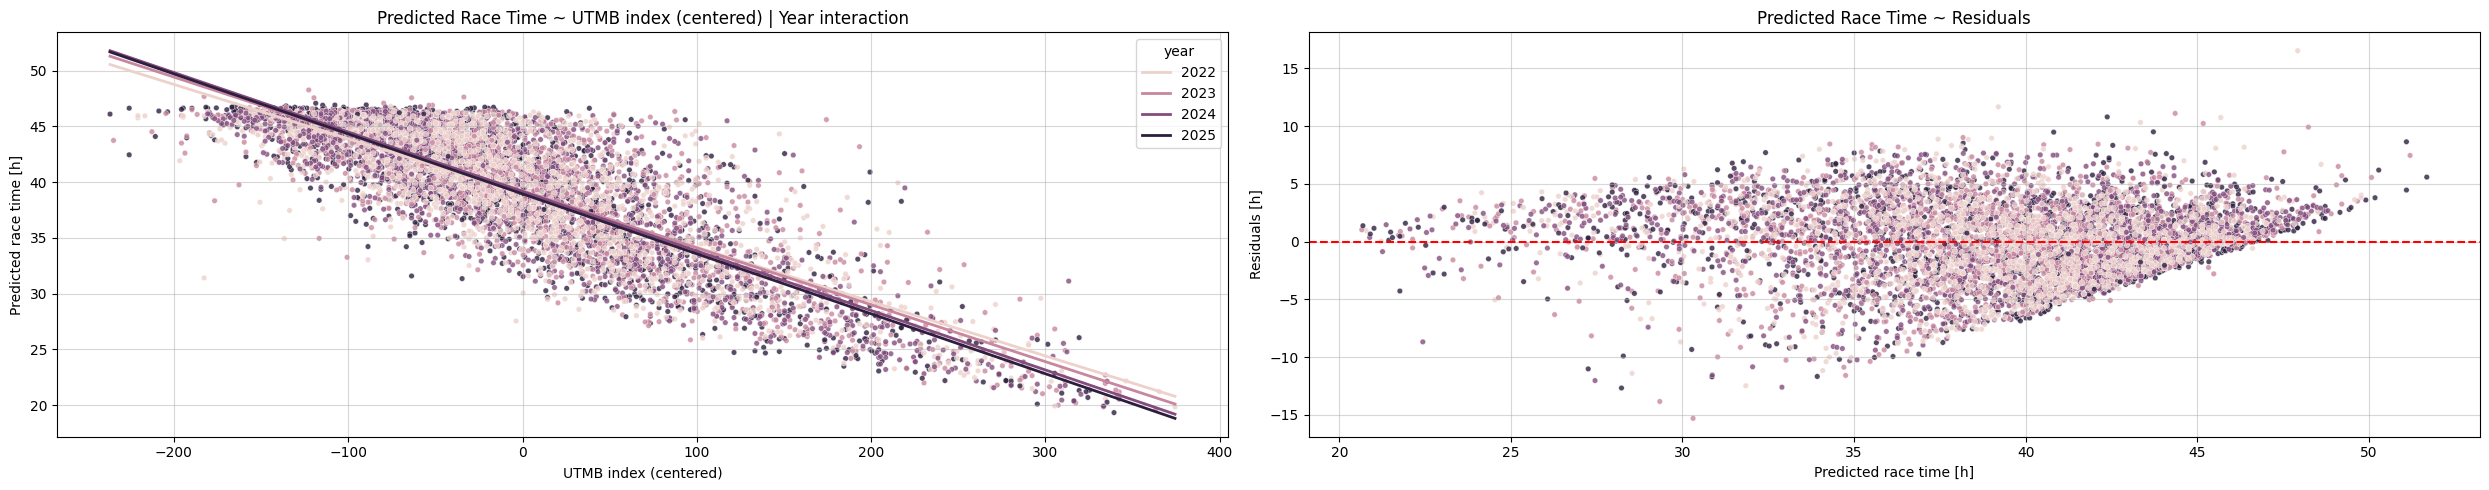

In [105]:
# Model diagnostic - Important

fig, ax = plt.subplots(1, 2, figsize = (25, 5))

# Prediction grid for model lines
utmb_index_grid = np.linspace(
    df_race_time_normalization["runner_overall_index_centered"].min(),
    df_race_time_normalization["runner_overall_index_centered"].max(),
    100,
)

pred_grid_df = pd.concat(
    [
        pd.DataFrame({
            "runner_overall_index_centered": utmb_index_grid,
            "year": year,
        })
        for year in sorted(df_race_time_normalization["year"].unique())
    ],
    ignore_index = True,
)

pred_grid_df = pred_grid_df.assign(
    runner_race_time_hours_pred = fit_race_time_normalization.predict(pred_grid_df)
)

# Model prediction lines by year
ax[0].set_title("Predicted Race Time ~ UTMB index (centered) | Year interaction")
sns.scatterplot(
    data = df_race_time_normalization, x = "runner_overall_index_centered", y = "runner_race_time_hours",
    hue = "year", s = 16, alpha = 0.8, ax = ax[0], legend = False,
)
sns.lineplot(
    data = pred_grid_df, x = "runner_overall_index_centered", y = "runner_race_time_hours_pred",
    hue = "year", linewidth = 2, ax = ax[0],
)
ax[0].set_xlabel("UTMB index (centered)")
ax[0].set_ylabel("Predicted race time [h]")

# Predicted values vs. residuals
ax[1].set_title("Predicted Race Time ~ Residuals")
sns.scatterplot(
    data = df_race_time_normalization, x = "runner_race_time_hours_pred", y = "runner_race_time_hours_residual_abs",
    hue = "year", s = 16, alpha = 0.8, ax = ax[1], legend = False,
)
ax[1].axhline(0, color = "red", linestyle = "--")
ax[1].set_xlabel("Predicted race time [h]")
ax[1].set_ylabel("Residuals [h]")

for i in [0, 1]:
    ax[i].grid(alpha = 0.5)

plt.tight_layout()
plt.show()

Normalize race times (residual based)
- Absolute residual 
    - Expected race time - Actual race time
    - 0.5 -> runner was 0.5 hours faster than expected
- Relative residual 
    - 1 - Actual race time / Expected race time
    - 0.05 -> runner was 5% faster than expected
- Percentile residual: 
    - Relative residual ranked by percentages
    - 0.9 -> runner performed better than 90% of field, relative expectation
- Normalized race time
    - Race time relative residual
    - Actual race time vs. Expected race time on percentage scale
    - On the same scale for all runners
    - Higher = better performance relative to expectation
        - 0 = exactly as expected
        - 0.05 = 5% faster than expected
        - -0.05 = 5% slower than expected

In [23]:
# Normalize race times - Residual based
df_race_time_normalization = (
    df_race_time_normalization
    .assign(
        runner_race_time_hours_residual_prc = lambda df: (
           1 - df["runner_race_time_hours"] / df["runner_race_time_hours_pred"]
        ),
        runner_race_time_performance_score = lambda df: (
            df["runner_race_time_hours_residual_prc"].rank(pct=True)
        )
    )
)

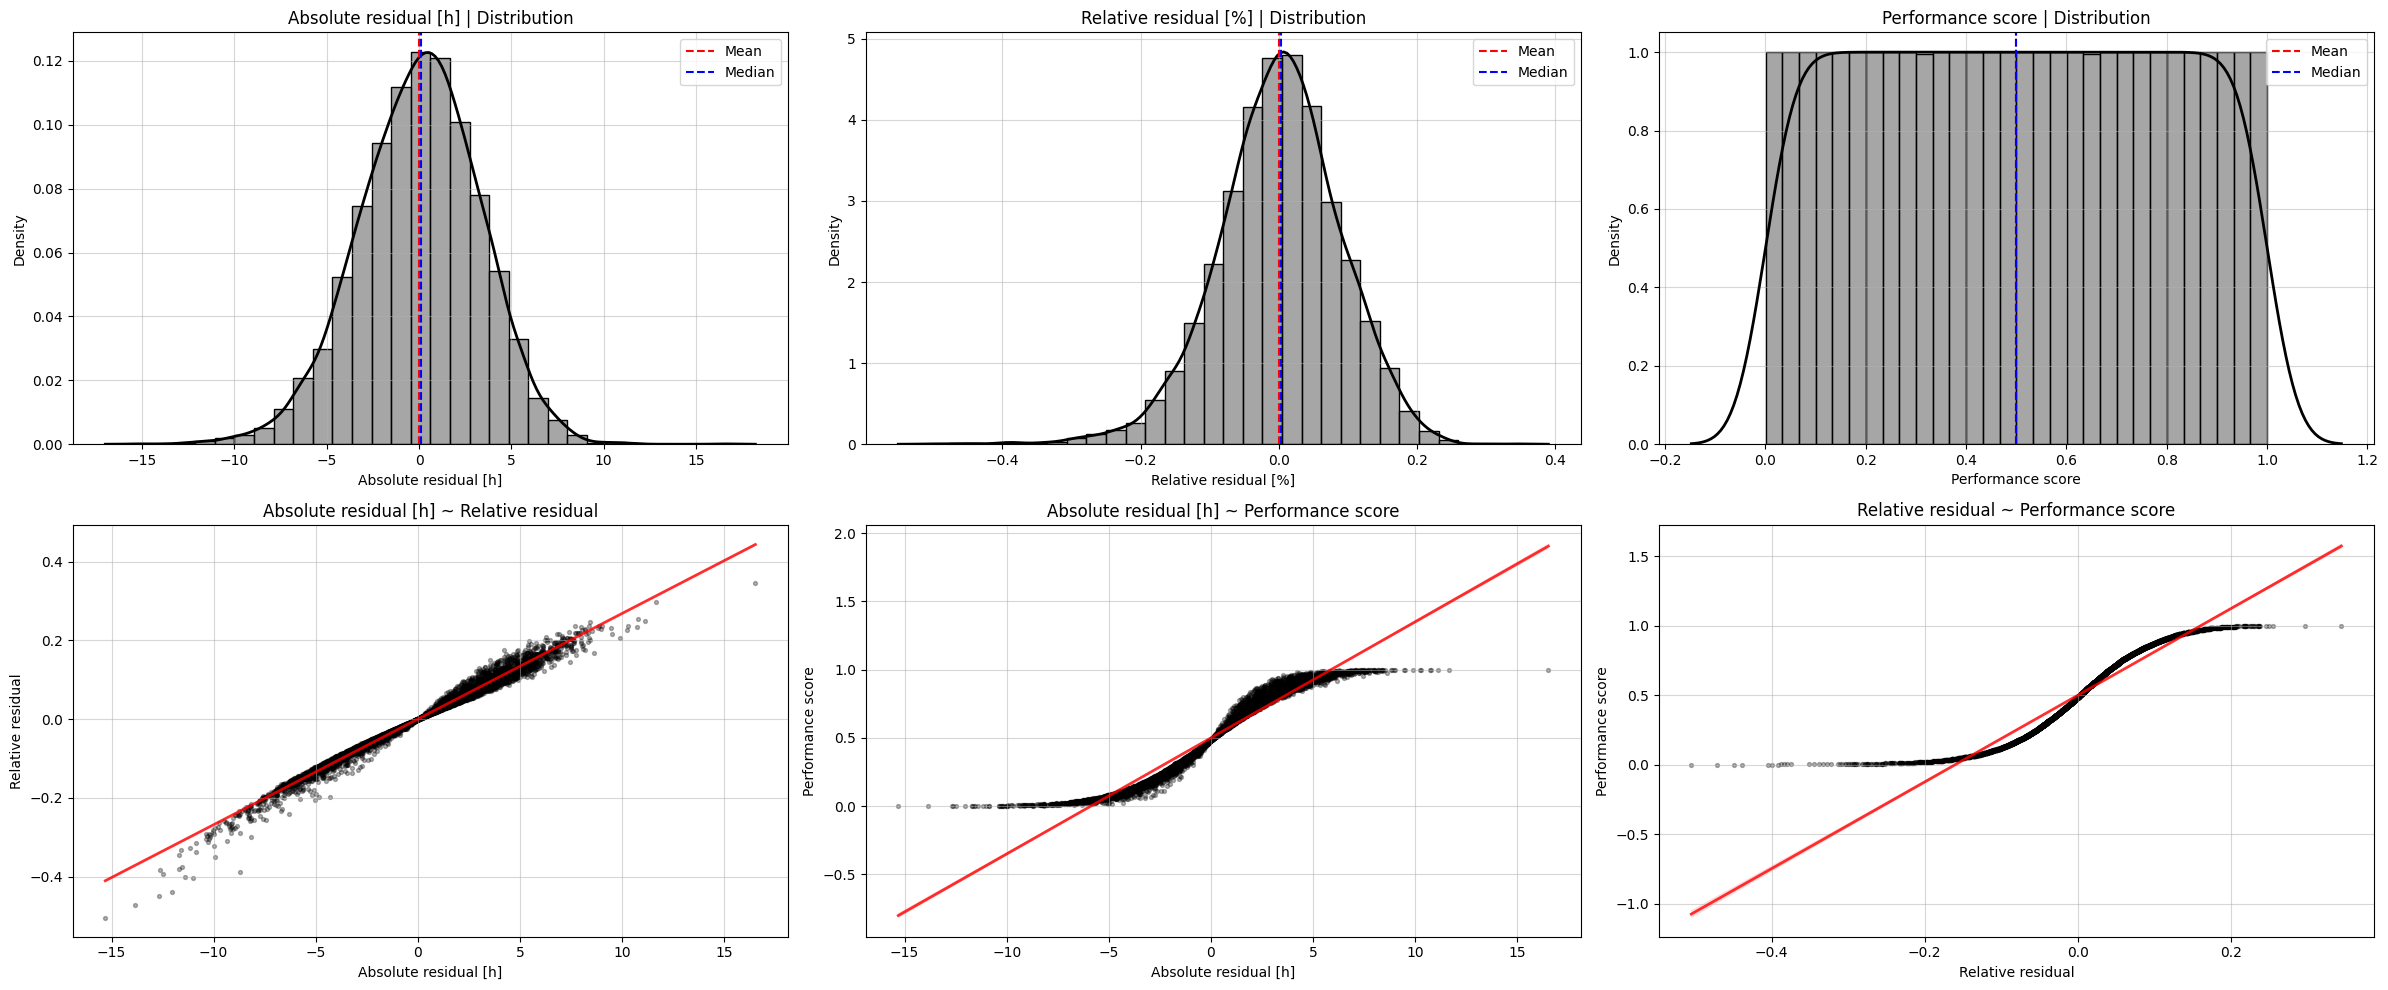

In [24]:
# Race time normalization diagnostics

plot_cols = [
    "runner_race_time_hours_residual_abs",
    "runner_race_time_hours_residual_prc",
    "runner_race_time_performance_score",
]

plot_titles = [
    "Absolute residual [h]",
    "Relative residual [%]",
    "Performance score",
]

scatter_pairs = [
    (
        "runner_race_time_hours_residual_abs",
        "runner_race_time_hours_residual_prc",
        "Absolute residual [h]",
        "Relative residual",
    ),
    (
        "runner_race_time_hours_residual_abs",
        "runner_race_time_performance_score",
        "Absolute residual [h]",
        "Performance score",
    ),
    (
        "runner_race_time_hours_residual_prc",
        "runner_race_time_performance_score",
        "Relative residual",
        "Performance score",
    ),
]

fig, ax = plt.subplots(2, 3, figsize = (24, 10))

# Top row: distributions
for i, (col, title) in enumerate(zip(plot_cols, plot_titles)):
    sns.histplot(
        data = df_race_time_normalization, x = col, 
        bins = 30, stat = "density", color = "grey", edgecolor = "black", alpha = 0.7, 
        ax = ax[0,i],
    )
    sns.kdeplot(
        data = df_race_time_normalization, x = col, 
        color = "black", linewidth = 2,
        ax = ax[0,i],
    )

    ax[0,i].axvline(
        df_race_time_normalization[col].mean(), 
        color = "red", linestyle = "--",
        label = "Mean",
    )
    ax[0,i].axvline(
        df_race_time_normalization[col].median(), 
        color = "blue", linestyle = "--",
        label = "Median",
    )

    ax[0,i].set_title(f"{title} | Distribution")
    ax[0,i].set_xlabel(title)
    ax[0,i].set_ylabel("Density")
    ax[0,i].legend()

# Bottom row: relationships
for i, (x_col, y_col, x_label, y_label) in enumerate(scatter_pairs):

    sns.regplot(
        data = df_race_time_normalization, x = x_col, y = y_col,
        scatter_kws = {"color": "black", "s": 8, "alpha": 0.3},
        line_kws = {"color": "red", "linewidth": 2, "alpha": 0.8},
        ax = ax[1,i],
    )

    ax[1,i].set_title(f"{x_label} ~ {y_label}")
    ax[1,i].set_xlabel(x_label)
    ax[1,i].set_ylabel(y_label)

for i in [0,1]:
    for j in [0,1,2]:
        ax[i,j].grid(alpha = 0.5)

plt.tight_layout()
plt.show()

In [25]:
# Merge back normalized race times to Pace analysis data
pacing_analysis_df = (
    pacing_analysis_df
    .merge(
        df_race_time_normalization[["runner_id", "runner_race_time_hours_residual_abs", "runner_race_time_hours_residual_prc", "runner_race_time_performance_score"]],
        on = "runner_id",
        how = "left",
    )
    .rename(columns={
        "runner_race_time_hours_residual_abs": "runner_race_time_hours_residual",
        "runner_race_time_hours_residual_prc": "runner_race_time_normalized",
        "runner_race_time_performance_score": "runner_rank_normalized",
    })
)


---
# Sector time normalization

- Raw sector times are not directly comparable because runners have different pre-race ability and sectors differ in distance, elevation, terrain.
- Normalization lets us compare runners sector times better.
- We normalize sector times so we can compare how runners distributed their race effort across sectors, relative to what would be expected for their ability, year, and sector.

Sector time options:
- sector_time_full_end_rest_min ~ movement into current checkpoint + rest at current checkpoint
- sector_time_full_start_rest_min ~ rest at previous checkpoint + movement into current checkpoint
- sector_time_full_no_rest_min ~ movement only

Decision: Sector time = movement only [sector_time_full_no_rest_min]
- (Movement) Time from the previous checkpoint departure to the current checkpoint arrival.
- How fast did the runner move through this sector?

In [26]:
# Analysis data - Take into account only movement sectors (some are rest only)
pacing_analysis_df = pacing_analysis_df.loc[
    lambda df: ~df["sector_is_rest_only"]
].reset_index(drop=True)

In [27]:
# Race/Year sector times analysis

for (race_id, year), race_year_df in (
    pacing_analysis_df
    .sort_values(["race_id", "year", "sector_number"])
    .groupby(["race_id", "year"])
):
    sector_summary_df = (
        race_year_df
        .groupby("sector_number")
        .agg(
            sector_checkpoint_id = ("sector_checkpoint_id", "first"),
            n_runners = ("runner_id", "nunique"),
            distance_km = ("sector_distance_km", "first"),
            avg_movement_time_min = ("sector_time_full_no_rest_min", "mean"),
            avg_rest_time_min = ("sector_rest_time_min", "mean"),
        )
        .reset_index()
        .sort_values("sector_number")
    )

    print(f"\nRace/Year: {race_id} / {year}")
    print("-" * 60)
    print(f"- Number of sectors: {sector_summary_df['sector_number'].nunique():,}")
    print(f"- Number of runners: {race_year_df['runner_id'].nunique():,}")
    display(sector_summary_df)

    # print("- Average sector times:")
    # for _, row in sector_summary_df.iterrows():
    #     print("     - Sector {}".format(row["sector_number"]))
    #     print("         - Distance {:,.1f}".format(row["distance_km"]))
    #     print("         - Movement {:,.1f}".format(row["avg_movement_time_min"]))
    #     print("         - Rest {:,.1f}".format(row["avg_rest_time_min"]))
    #     print("         - Runners {:,.1f}".format(row["n_runners"]))



Race/Year: utmb / 2022
------------------------------------------------------------
- Number of sectors: 24
- Number of runners: 1,789


,sector_number,sector_checkpoint_id,n_runners,distance_km,avg_movement_time_min,avg_rest_time_min
0,1,2,1789,13.309836,109.563890,0.000000
1,2,3,1789,8.370091,59.739881,0.005925
2,3,4,1789,9.649931,91.422869,0.702040
3,4,5,1789,8.329963,102.111913,0.023244
4,5,6,1789,5.619977,94.770184,0.020617
5,6,7,1789,5.000000,42.986818,14.650093
6,7,8,1789,10.640000,136.160837,0.000699
7,8,11,1789,7.150077,94.109401,0.000000
8,9,12,1789,3.990039,73.683893,0.005702
9,10,13,1789,4.490050,41.444957,0.000000



Race/Year: utmb / 2023
------------------------------------------------------------
- Number of sectors: 23
- Number of runners: 1,757


,sector_number,sector_checkpoint_id,n_runners,distance_km,avg_movement_time_min,avg_rest_time_min
0,1,2,1757,13.060228,109.715898,0.000000
1,2,3,1757,8.380042,60.200209,0.035231
2,3,4,1757,10.019960,96.362929,1.391074
3,4,5,1757,8.630081,101.782669,0.017511
4,5,6,1757,5.669959,95.389168,0.000000
5,6,7,1757,5.010008,42.665794,14.522908
6,7,8,1757,10.550028,137.419155,0.132821
7,8,11,1757,7.260016,94.591491,3.512493
8,9,12,1757,3.809981,69.964825,0.011696
9,10,13,1757,4.510040,40.929112,0.792573



Race/Year: utmb / 2024
------------------------------------------------------------
- Number of sectors: 25
- Number of runners: 1,760


,sector_number,sector_checkpoint_id,n_runners,distance_km,avg_movement_time_min,avg_rest_time_min
0,1,2,1760,13.190362,109.570616,0.000000
1,2,3,1760,8.489939,61.450057,0.012661
2,3,4,1760,9.659906,91.593292,3.530360
3,4,5,1760,4.280054,39.778684,0.000000
4,5,6,1760,4.370059,60.371364,0.062547
5,6,7,1760,5.830036,94.867709,0.005199
6,7,8,1760,5.279979,41.676790,15.322462
7,8,9,1760,10.790064,139.193014,0.076061
8,9,11,1760,7.330054,92.069934,1.071866
9,10,12,1760,4.000000,71.495151,0.002453



Race/Year: utmb / 2025
------------------------------------------------------------
- Number of sectors: 23
- Number of runners: 1,665


,sector_number,sector_checkpoint_id,n_runners,distance_km,avg_movement_time_min,avg_rest_time_min
0,1,2,1665,14.560041,121.555860,0.000000
1,2,3,1665,8.490028,60.844631,0.000000
2,3,4,1665,9.659864,88.143473,0.174004
3,4,6,1665,8.630009,105.498573,0.210040
4,5,7,1665,5.830004,101.434275,0.411171
5,6,8,1665,5.280000,56.098298,17.753373
6,7,9,1665,10.789980,143.879144,0.013403
7,8,11,1665,4.870184,50.142703,2.167497
8,9,12,1665,3.989994,72.730153,0.002262
9,10,13,1665,4.590060,43.860282,0.000000


We will not normalize sector times directly. Instead, we normalize sector shares.
- If we normalized raw sector times directly, then the sector residuals would mostly add up to the runner's normalized total race time.
    - Total race time is just the sum of sector times.
    - Raw sector-time normalization would mostly tell us whether the runner was faster or slower than expected overall.
    - For pacing, we want to remove the overall performance level and study the shape of the race
- Sector shares force each runner's sector profile to sum to 1.
- Our interest: How did the runner distribute energy (time) across the course?
- Sector-share normalization measures pacing distribution - relative sector aggressiveness.
- Did the runner spend more or less of their race in this sector than expected?

In [28]:
# Calculate sector shares for each runner [runner_sector_time_share] (runner relative sector allocation from total moving time)

pacing_analysis_df = (
    pacing_analysis_df
    .assign(
        # Total moving time for each runner
        runner_total_moving_time_min = lambda df: (
            df.groupby("runner_id")["sector_time_full_no_rest_min"].transform("sum")
        ),

        # Runner-relative sector allocation
        runner_sector_time_share = lambda df: (
            df["sector_time_full_no_rest_min"] / df["runner_total_moving_time_min"]
        ),
    )
)

# Sanity check
assert np.isclose(
    pacing_analysis_df.groupby("runner_id")["runner_sector_time_share"].sum(),
    1,
    atol = 1e-6
).all(), "runner_sector_time_share does not sum to 1 for every runner."

In [29]:
# Sector time/share normalization data
display(
    pacing_analysis_df[[
            "runner_id",
            "race_id",
            "year",
            "sector_number",
            "sector_time_full_no_rest_min",
            "runner_total_moving_time_min",
            "runner_sector_time_share",
    ]]
)

,runner_id,race_id,year,sector_number,sector_time_full_no_rest_min,runner_total_moving_time_min,runner_sector_time_share
0,1,utmb,2022,1,68.250000,1173.250000,0.058172
1,1,utmb,2022,2,38.416667,1173.250000,0.032744
2,1,utmb,2022,3,50.666667,1173.250000,0.043185
3,1,utmb,2022,4,53.116667,1173.250000,0.045273
4,1,utmb,2022,5,NaN,1173.250000,NaN
...,...,...,...,...,...,...,...
165637,10563,utmb,2024,22,51.966667,1644.883333,0.031593
165638,10563,utmb,2024,23,62.833333,1644.883333,0.038199
165639,10563,utmb,2024,24,71.333333,1644.883333,0.043367
165640,10563,utmb,2024,26,136.183333,1644.883333,0.082792


We see some sector times/shares are missing - investigate
- For sector-share normalization, each runner needs a complete sector profile - sector shares should describe the full race distribution.
- For runners with exactly one missing movement-sector time, we impute the missing value from total race time and total sector times from known sectors.
- Because rest time at the missing checkpoint may also be unknown, we first estimate that rest time using the median rest time for the same race/year/sector. 
- Runners with more than one missing movement sector are removed.

In [30]:
# Check (1)

cols_to_check = [
    "sector_time_full_no_rest_min",
    "runner_sector_time_share",
]

# Overall
print("Overall missingness:")
print("----------------------------------------")
for col in cols_to_check:
    runners_with_missing = (
        pacing_analysis_df
        .loc[pacing_analysis_df[col].isna(), "runner_id"]
        .nunique()
    )
    n_missing = pacing_analysis_df[col].isna().sum()
    missing_share = pacing_analysis_df[col].isna().mean() * 100

    print(" - {}".format(col))
    print("     - {:,} missing rows ({:.2f}%)".format(n_missing, missing_share))
    print("     - {:,} runners with missing data ({:.2f}%)".format(
        runners_with_missing,
        runners_with_missing / pacing_analysis_df["runner_id"].nunique() * 100,
    ))

# By year
print("\nYear-based missingness:")
print("----------------------------------------")
for year, df_year in pacing_analysis_df.groupby("year"):
    print("\nYear: {}".format(year))
    for col in cols_to_check:
        n_missing = df_year[col].isna().sum()
        missing_share = df_year[col].isna().mean() * 100
        print("   - {}: {:,} missing ({:.2f}%)".format(col, n_missing, missing_share))

# By sector
print("\nSector-based missingness:")
print("----------------------------------------")
for sector_number, df_sector in pacing_analysis_df.groupby("sector_number"):
    print("\nSector: {}".format(sector_number))
    for col in cols_to_check:
        n_missing = df_sector[col].isna().sum()
        missing_share = df_sector[col].isna().mean() * 100
        print("   - {}: {:,} missing ({:.2f}%)".format(col, n_missing, missing_share))

Overall missingness:
----------------------------------------
 - sector_time_full_no_rest_min
     - 285 missing rows (0.17%)
     - 280 runners with missing data (4.02%)
 - runner_sector_time_share
     - 285 missing rows (0.17%)
     - 280 runners with missing data (4.02%)

Year-based missingness:
----------------------------------------

Year: 2022
   - sector_time_full_no_rest_min: 105 missing (0.24%)
   - runner_sector_time_share: 105 missing (0.24%)

Year: 2023
   - sector_time_full_no_rest_min: 33 missing (0.08%)
   - runner_sector_time_share: 33 missing (0.08%)

Year: 2024
   - sector_time_full_no_rest_min: 48 missing (0.11%)
   - runner_sector_time_share: 48 missing (0.11%)

Year: 2025
   - sector_time_full_no_rest_min: 99 missing (0.26%)
   - runner_sector_time_share: 99 missing (0.26%)

Sector-based missingness:
----------------------------------------

Sector: 1
   - sector_time_full_no_rest_min: 5 missing (0.07%)
   - runner_sector_time_share: 5 missing (0.07%)

Sector: 2


In [31]:
# Check (2)

runner_sector_time_completeness_df = (
    pacing_analysis_df
    .assign(
        sector_time_full_no_rest_is_missing = lambda df: df["sector_time_full_no_rest_min"].isna()
    )
    .groupby(["race_id", "year", "runner_id"], as_index = False)
    .agg(
        number_of_sectors = ("sector_number", "nunique"),
        missing_sector_time_rows = ("sector_time_full_no_rest_is_missing", "sum"),
    )
    .assign(
        runner_has_complete_sector_times = lambda df: df["missing_sector_time_rows"] == 0,
        runner_has_one_missing_sector_time = lambda df: df["missing_sector_time_rows"] == 1,
        runner_has_more_than_one_missing_sector_time = lambda df: df["missing_sector_time_rows"] > 1,
    )
)

print("Runner sector-time completeness")
print("----------------------------------------")
print("Number of runners: {:,}".format(runner_sector_time_completeness_df["runner_id"].nunique()))
print("Number of complete runners: {:,}".format(runner_sector_time_completeness_df["runner_has_complete_sector_times"].sum()))
print("Number of incomplete runners: {:,}".format((~runner_sector_time_completeness_df["runner_has_complete_sector_times"]).sum()))
print("Incomplete runners share: {:.2f}%".format((~runner_sector_time_completeness_df["runner_has_complete_sector_times"]).mean() * 100))

print("\nMissing sector-time detail")
print("----------------------------------------")
print("Number of runners with exactly 1 missing sector time: {:,}".format(runner_sector_time_completeness_df["runner_has_one_missing_sector_time"].sum()))
print("Share of runners with exactly 1 missing sector time: {:.2f}%".format(runner_sector_time_completeness_df["runner_has_one_missing_sector_time"].mean() * 100))
print("Number of runners with more than 1 missing sector time: {:,}".format(runner_sector_time_completeness_df["runner_has_more_than_one_missing_sector_time"].sum()))
print("Share of runners with more than 1 missing sector time: {:.2f}%".format(runner_sector_time_completeness_df["runner_has_more_than_one_missing_sector_time"].mean() * 100))

Runner sector-time completeness
----------------------------------------
Number of runners: 6,971
Number of complete runners: 6,691
Number of incomplete runners: 280
Incomplete runners share: 4.02%

Missing sector-time detail
----------------------------------------
Number of runners with exactly 1 missing sector time: 275
Share of runners with exactly 1 missing sector time: 3.94%
Number of runners with more than 1 missing sector time: 5
Share of runners with more than 1 missing sector time: 0.07%


In [32]:
# Impute runners with exactly one missing movement-sector time

# Median rest time for same race/year/sector
sector_rest_time_median_df = (
    pacing_analysis_df
    .loc[lambda df: df["sector_time_full_no_rest_min"].notna()]
    .groupby(["race_id", "year", "sector_number"], as_index = False)
    .agg(sector_rest_time_median_min = ("sector_rest_time_min", "median"))
)

# Runner-level missing sector summary
runner_missing_sector_time_df = (
    pacing_analysis_df
    .assign(sector_time_full_no_rest_is_missing = lambda df: df["sector_time_full_no_rest_min"].isna())
    .groupby(["race_id", "year", "runner_id"], as_index = False)
    .agg(
        number_of_missing_sector_times = ("sector_time_full_no_rest_is_missing", "sum"),
        runner_race_time_min = ("runner_race_time_hours", lambda x: x.iloc[0] * 60),
        known_moving_time_min = ("sector_time_full_no_rest_min", "sum"),
        known_rest_time_min = ("sector_rest_time_min", "sum"),
    )
)

# Add sector median rest and runner-level data
pacing_analysis_df = (
    pacing_analysis_df
    .merge(
        sector_rest_time_median_df,
        on = ["race_id", "year", "sector_number"],
        how = "left",
        validate = "m:1",
    )
    .merge(
        runner_missing_sector_time_df,
        on = ["race_id", "year", "runner_id"],
        how = "left",
        validate = "m:1",
    )
    .assign(
        sector_time_full_no_rest_was_imputed = lambda df: df["sector_time_full_no_rest_min"].isna() & (df["number_of_missing_sector_times"] == 1),
        sector_rest_time_min_was_imputed = lambda df: df["sector_time_full_no_rest_was_imputed"],

        # Use median rest time for the missing checkpoint
        sector_rest_time_min = lambda df: np.where(
            df["sector_rest_time_min_was_imputed"],
            df["sector_rest_time_median_min"],
            df["sector_rest_time_min"],
        ),

        # Missing movement time = total race time - known movement - known rest - imputed missing rest
        sector_time_full_no_rest_min = lambda df: np.where(
            df["sector_time_full_no_rest_was_imputed"],
            (
                df["runner_race_time_min"]
                - df["known_moving_time_min"]
                - df["known_rest_time_min"]
                - df["sector_rest_time_median_min"]
            ),
            df["sector_time_full_no_rest_min"],
        ),
    )
)

In [33]:
# Remove runners where movement-sector timing is still incomplete
incomplete_runner_ids = (
    pacing_analysis_df
    .loc[lambda df: df["sector_time_full_no_rest_min"].isna(), "runner_id"]
    .unique()
)

pacing_analysis_df = (
    pacing_analysis_df
    .loc[lambda df: ~df["runner_id"].isin(incomplete_runner_ids)]
    .reset_index(drop = True)
)

In [34]:
# Recalculate sector shares and total moving time after imputation

pacing_analysis_df = (
    pacing_analysis_df
    .assign(
        # Total moving time for each runner
        runner_total_moving_time_min = lambda df: (
            df.groupby("runner_id")["sector_time_full_no_rest_min"].transform("sum")
        ),

        # Runner-relative sector allocation
        runner_sector_time_share = lambda df: (
            df["sector_time_full_no_rest_min"] / df["runner_total_moving_time_min"]
        ),
    )
)

In [35]:
# Assertions

assert (
    pacing_analysis_df["sector_time_full_no_rest_min"].notna()
).all(), "Some movement-sector times are still missing."

assert (
    pacing_analysis_df["runner_total_moving_time_min"].notna()
).all(), "Some runner total moving times are missing."

assert (
    pacing_analysis_df["runner_sector_time_share"].notna()
).all(), "Some runner sector time shares are missing."

assert np.isclose(
    pacing_analysis_df.groupby("runner_id")["runner_sector_time_share"].sum(),
    1,
    atol = 1e-6,
).all(), "runner_sector_time_share does not sum to 1 for every runner."

In [36]:
# Sector time/share normalization data
display(
    pacing_analysis_df[[
            "runner_id",
            "race_id",
            "year",
            "sector_number",
            "sector_time_full_no_rest_min",
            "runner_total_moving_time_min",
            "runner_sector_time_share",
    ]]
)

,runner_id,race_id,year,sector_number,sector_time_full_no_rest_min,runner_total_moving_time_min,runner_sector_time_share
0,1,utmb,2022,1,68.250000,1178.883333,0.057894
1,1,utmb,2022,2,38.416667,1178.883333,0.032587
2,1,utmb,2022,3,50.666667,1178.883333,0.042979
3,1,utmb,2022,4,53.116667,1178.883333,0.045057
4,1,utmb,2022,5,5.633333,1178.883333,0.004779
...,...,...,...,...,...,...,...
165517,10563,utmb,2024,22,51.966667,1644.883333,0.031593
165518,10563,utmb,2024,23,62.833333,1644.883333,0.038199
165519,10563,utmb,2024,24,71.333333,1644.883333,0.043367
165520,10563,utmb,2024,26,136.183333,1644.883333,0.082792


Sector share normalization
- Did runner spend more/less of their race here than expected for this sector and ability?
- Expected sector share based on ability, year, and sector

In [37]:
# Sector share normalization data - one row per runner/sector
df_sector_share_normalization = (
    pacing_analysis_df
    .assign(
        runner_overall_index_centered = lambda df: (
            df["runner_overall_index"] - df["runner_overall_index"].mean()
        )
    )
    [["runner_id", "race_id", "runner_sector_time_share", "runner_overall_index_centered", "year", "sector_number"]]
    .dropna(how="any")
    .reset_index(drop=True)
    .copy()
)

In [38]:
# Model - Fit & Predict

# Fit 
model_sector_share_normalization = smf.ols(
    formula = "runner_sector_time_share ~ C(year):C(sector_number) + runner_overall_index_centered:C(sector_number)",
    data = df_sector_share_normalization,
)
fit_sector_share_normalization = model_sector_share_normalization.fit()

# Predict & store predictions
y_pred_sector_share_normalization = fit_sector_share_normalization.predict(df_sector_share_normalization)
df_sector_share_normalization["runner_sector_time_share_pred"] = y_pred_sector_share_normalization

# Sanity checks - share are [0,1]
assert np.equal(
    df_sector_share_normalization["runner_sector_time_share_pred"] <= 0,
    0
).all(), "there are some negative runner_sector_time_share predictions"

assert np.equal(
    df_sector_share_normalization["runner_sector_time_share_pred"] > 1,
    0
).all(), "there are some >1 runner_sector_time_share predictions"

In [39]:
# Coefficients
coef_sector_share_normalization_df = (
    pd.DataFrame({
        "coef": fit_sector_share_normalization.params,
        "std_err": fit_sector_share_normalization.bse,
        "p_value": fit_sector_share_normalization.pvalues,
        "ci_lower": fit_sector_share_normalization.conf_int()[0],
        "ci_upper": fit_sector_share_normalization.conf_int()[1],
    })
    .reset_index(names="term")
    .assign(abs_coef = lambda df: df["coef"].abs())
)

display(
    coef_sector_share_normalization_df
    .sort_values("abs_coef", ascending=False)
)

,term,coef,std_err,p_value,ci_lower,ci_upper,abs_coef
0,Intercept,5.027261e-02,1.239755e-04,0.000000e+00,5.002962e-02,5.051560e-02,5.027261e-02
103,C(year)[T.2024]:C(sector_number)[26],4.930791e-02,1.739695e-04,0.000000e+00,4.896693e-02,4.964889e-02,4.930791e-02
78,C(year)[T.2023]:C(sector_number)[18],4.883944e-02,1.742645e-04,0.000000e+00,4.849788e-02,4.918099e-02,4.883944e-02
80,C(year)[T.2025]:C(sector_number)[18],4.773600e-02,1.768301e-04,0.000000e+00,4.738942e-02,4.808258e-02,4.773600e-02
46,C(year)[T.2024]:C(sector_number)[7],-4.327725e-02,1.739693e-04,0.000000e+00,-4.361823e-02,-4.293628e-02,4.327725e-02
...,...,...,...,...,...,...,...
95,C(year)[T.2025]:C(sector_number)[23],-1.594412e-17,1.390281e-19,0.000000e+00,-1.621661e-17,-1.567163e-17,1.594412e-17
100,C(year)[T.2024]:C(sector_number)[25],1.340129e-17,1.479888e-19,0.000000e+00,1.311123e-17,1.369134e-17,1.340129e-17
105,C(year)[T.2023]:C(sector_number)[27],-5.294138e-18,1.198477e-19,0.000000e+00,-5.529037e-18,-5.059239e-18,5.294138e-18
107,C(year)[T.2025]:C(sector_number)[27],4.359719e-18,9.695963e-20,0.000000e+00,4.169680e-18,4.549758e-18,4.359719e-18


In [40]:
# "Normalize" sector share predictions,so they again sum up to 1
df_sector_share_normalization = (
    df_sector_share_normalization
    .assign(
        runner_sector_time_share_pred_sum = lambda df: (
            df.groupby(["race_id", "year", "runner_id"])
            ["runner_sector_time_share_pred"]
            .transform("sum")
        ),
        runner_sector_time_share_pred = lambda df: (
            df["runner_sector_time_share_pred"]
            / df["runner_sector_time_share_pred_sum"]
        ),
    )
)

# Check
sector_share_normalization_check_df = (
    df_sector_share_normalization
    .groupby(["race_id", "year", "runner_id"])
    .agg(
        runner_sector_time_share_sum = ("runner_sector_time_share", "sum"),
        runner_sector_time_share_pred_sum = ("runner_sector_time_share_pred", "sum"),
    )
    .reset_index()
)

assert np.allclose(
    sector_share_normalization_check_df["runner_sector_time_share_sum"],
    1,
    atol = 1e-6,
), "Actual sector time shares do not sum to 1 for every runner."

assert np.allclose(
    sector_share_normalization_check_df["runner_sector_time_share_pred_sum"],
    1,
    atol = 1e-6,
), "Predicted sector time shares do not sum to 1 for every runner."

Sector pace normalization - description of a runner's pacing in each sector

- Sector time share [runner_sector_time_share]
    - Fraction of the runner's total moving race time spent in this sector.
    - 0.08 -> this sector took 8% of the runner's total moving time.
    - Runner-relative, but not yet good/bad by itself.

- Expected sector time share [runner_sector_time_share_pred]
    - Expected share for a runner with this UTMB index, in this year, in this sector.

- Sector pacing residual [sector_pacing_residual]
    - Expected share - actual share.
    - Positive -> runner spent less race share than expected in this sector.
    - 0.05 -> runner spent 5 percentage points less than expected.

- Normalized sector pacing [sector_pacing_normalized]
    - 1 - actual share / expected share
    - Positive -> runner spent relatively less time than expected.
    - 0.20 -> runner spent 20% less time share than expected.

- Overall sector pacing rank [sector_pacing_rank_overall]
    - Percentile rank of sector_pacing_normalized across all runner-sector observations.
    - Higher -> stronger/more aggressive sector relative to all observations.

- Specific sector pacing rank [sector_pacing_rank_specific]
    - Percentile rank of sector_pacing_normalized within the same race/year/sector.
    - Higher -> stronger/more aggressive sector relative to runners in the same sector.

In [41]:
# Normalize sector shares - Residual based & "rename" to [sector_pacing] instead of sector_time_share ...
df_sector_share_normalization = (
    df_sector_share_normalization
    .assign(
        sector_pacing_residual = lambda df: (
            df["runner_sector_time_share_pred"] - df["runner_sector_time_share"]
        ),
        sector_pacing_normalized = lambda df: (
           1 - df["runner_sector_time_share"] / df["runner_sector_time_share_pred"]
        ),
        sector_pacing_rank_overall = lambda df: (
            df["sector_pacing_normalized"].rank(pct = True)
        ),
        sector_pacing_rank_specific = lambda df: (
            df.groupby(["race_id", "year", "sector_number"])
            ["sector_pacing_normalized"].rank(pct = True)
        )
    )
    .rename(columns = {
        "runner_sector_time_share": "sector_pacing_absolute",
        "runner_sector_time_share_pred": "sector_pacing_absolute_pred",
    })
)

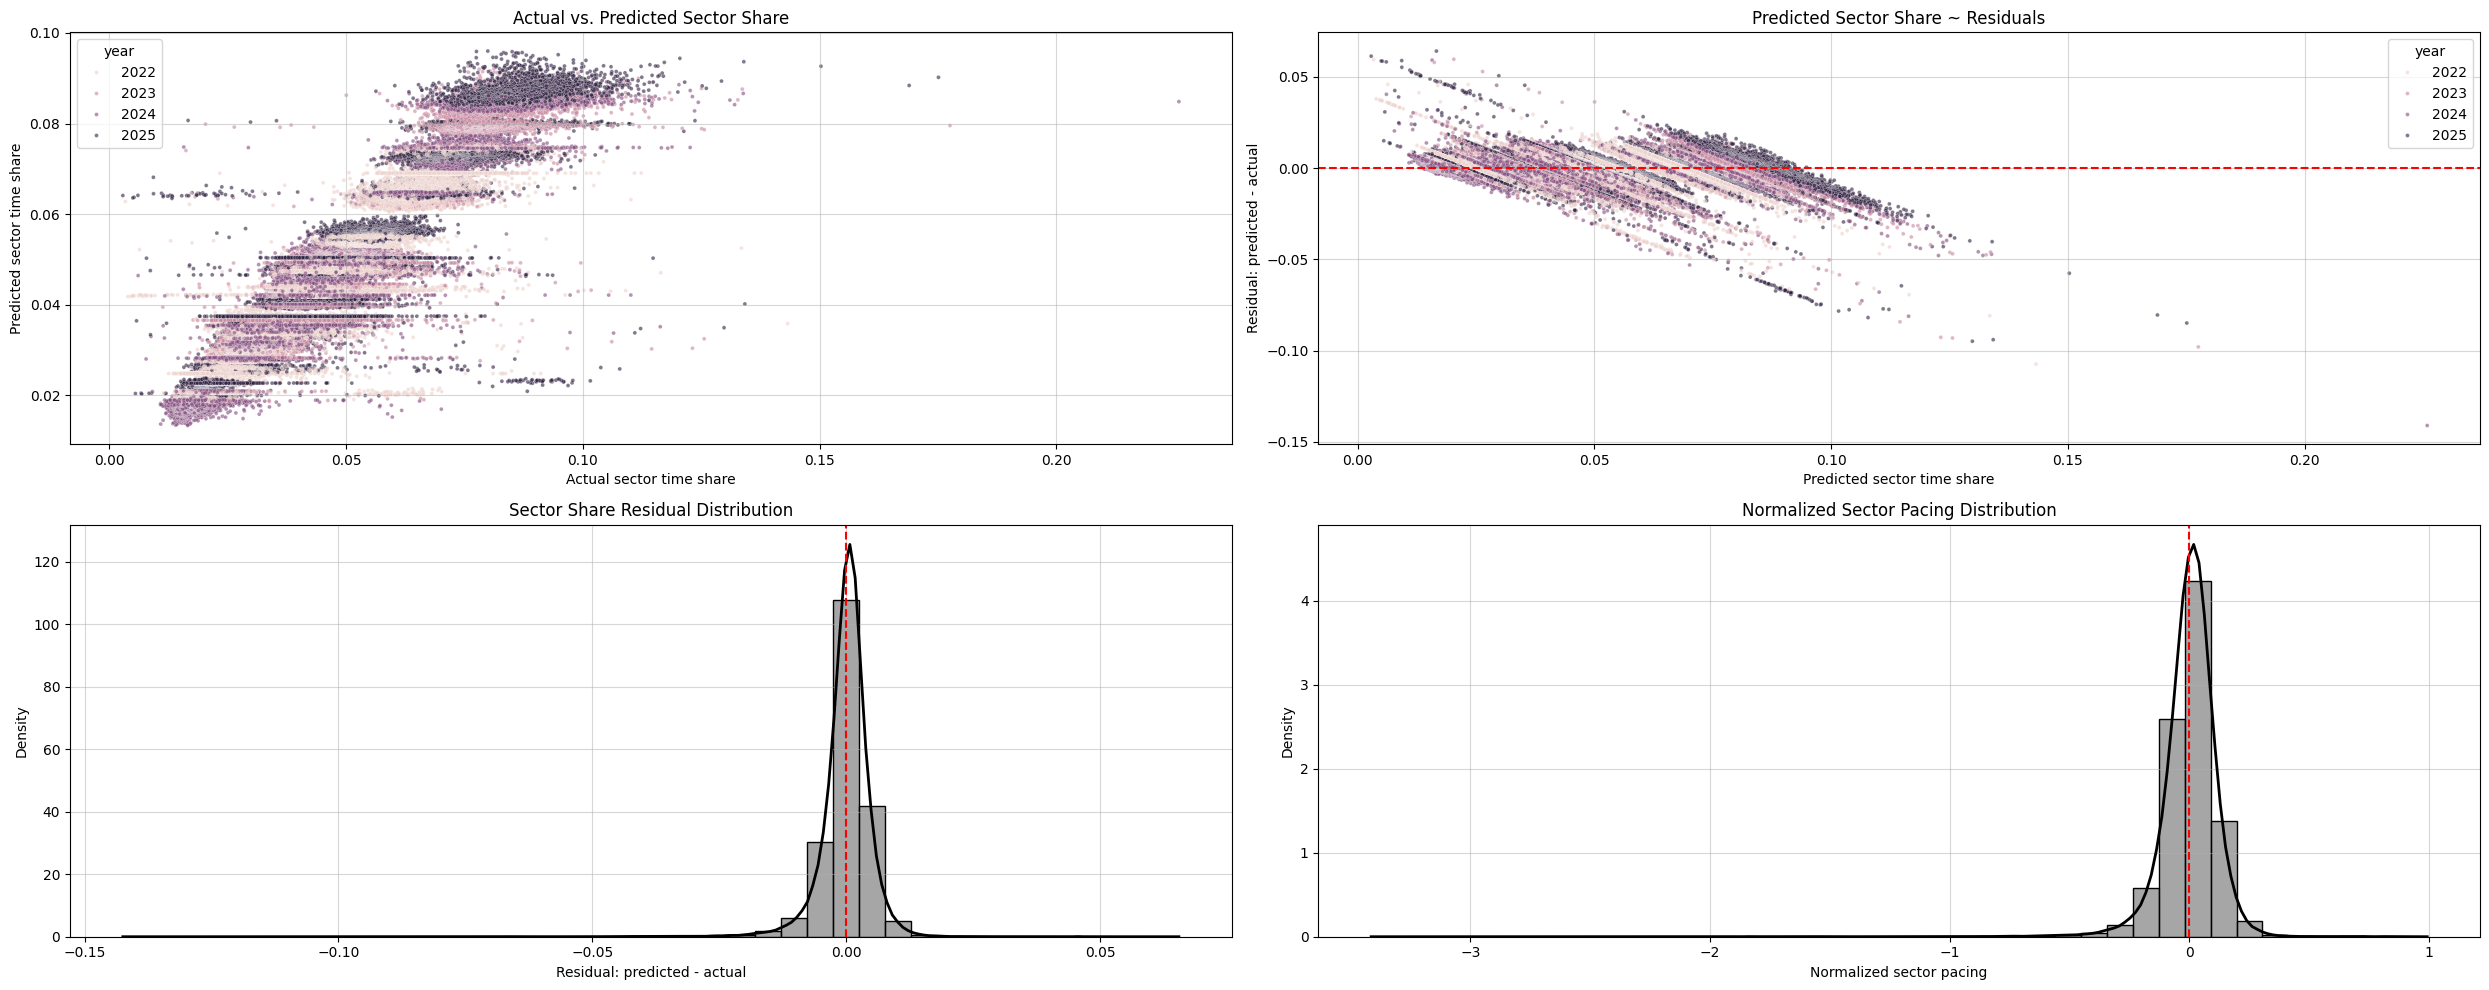

In [106]:
# Sector share normalization diagnostics
fig, ax = plt.subplots(2, 2, figsize = (25, 10))

# Actual vs predicted
sns.scatterplot(
    data = df_sector_share_normalization, x = "sector_pacing_absolute", y = "sector_pacing_absolute_pred",
    hue = "year", s = 8, alpha = 0.6, 
    ax = ax[0,0],
)
ax[0,0].set_title("Actual vs. Predicted Sector Share")
ax[0,0].set_xlabel("Actual sector time share")
ax[0,0].set_ylabel("Predicted sector time share")

# Predicted vs residuals
sns.scatterplot(
    data = df_sector_share_normalization, x = "sector_pacing_absolute", y = "sector_pacing_residual",
    hue = "year", s = 8, alpha = 0.6,  legend = True,
    ax = ax[0,1],
)
ax[0,1].axhline(0, color = "red", linestyle = "--")
ax[0,1].set_title("Predicted Sector Share ~ Residuals")
ax[0,1].set_xlabel("Predicted sector time share")
ax[0,1].set_ylabel("Residual: predicted - actual")

# Residual distribution
sns.histplot(
    data = df_sector_share_normalization, x = "sector_pacing_residual",
    bins = 40, stat = "density", color = "grey", edgecolor = "black", alpha = 0.7,
    ax = ax[1,0],
)
sns.kdeplot(
    data = df_sector_share_normalization, x = "sector_pacing_residual", color = "black", linewidth = 2,
    ax = ax[1,0],
)
ax[1,0].axvline(0, color = "red", linestyle = "--")
ax[1,0].set_title("Sector Share Residual Distribution")
ax[1,0].set_xlabel("Residual: predicted - actual")

# Relative normalized sector pacing distribution
sns.histplot(
    data = df_sector_share_normalization, x = "sector_pacing_normalized",
    bins = 40, stat = "density", color = "grey", edgecolor = "black", alpha = 0.7,
    ax = ax[1,1],
)
sns.kdeplot(
    data = df_sector_share_normalization, x = "sector_pacing_normalized", color = "black", linewidth = 2,
    ax = ax[1,1],
)
ax[1,1].axvline(0, color = "red", linestyle = "--")
ax[1,1].set_title("Normalized Sector Pacing Distribution")
ax[1,1].set_xlabel("Normalized sector pacing")

for i in [0,1]:
    for j in [0,1]:
        ax[i,j].grid(alpha = 0.5)

plt.tight_layout()
plt.show()

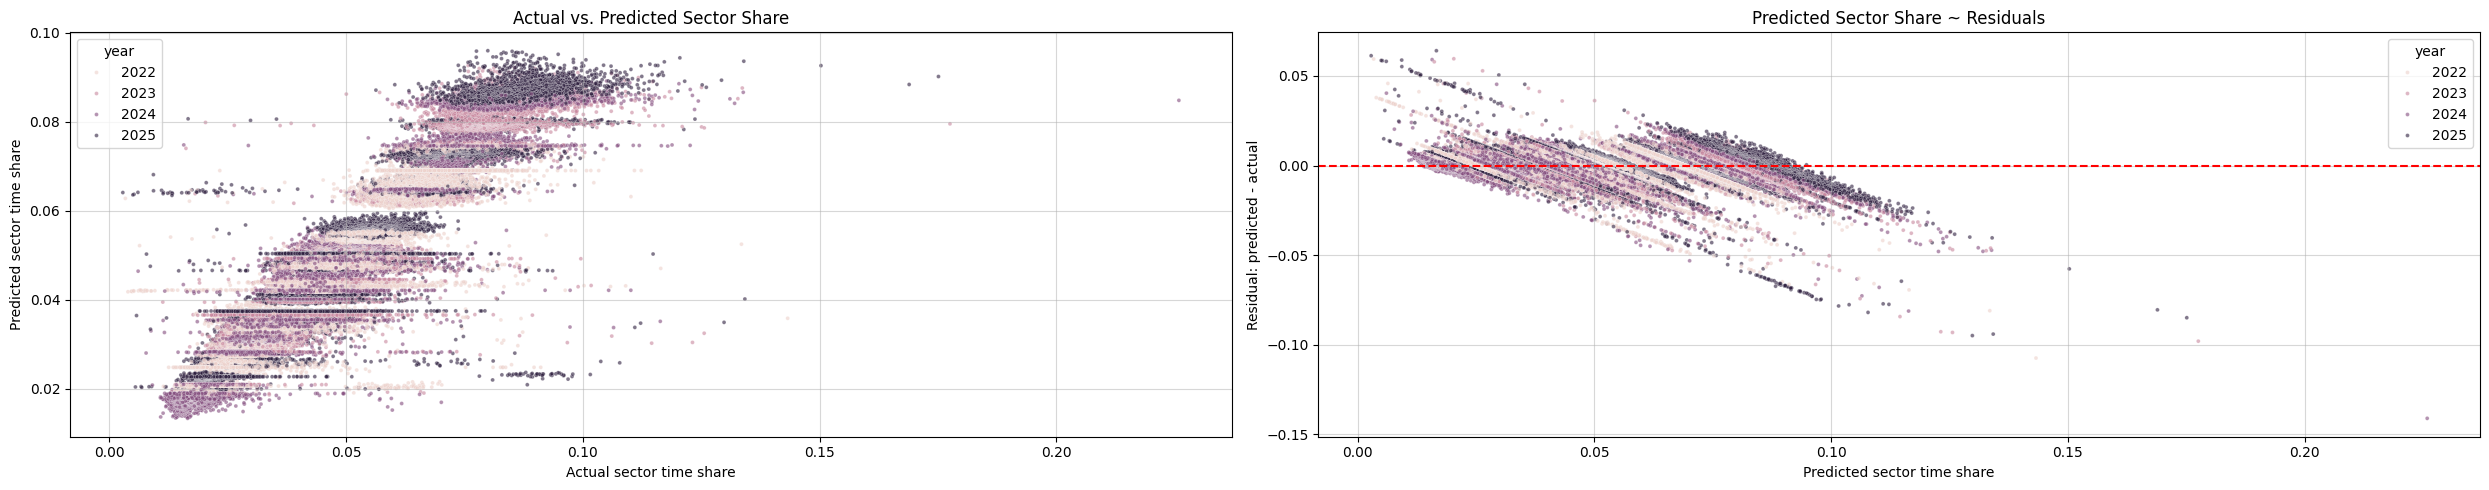

In [107]:
# Sector share normalization diagnostics - Important
fig, ax = plt.subplots(1, 2, figsize = (25,5))

# Actual vs predicted
sns.scatterplot(
    data = df_sector_share_normalization, x = "sector_pacing_absolute", y = "sector_pacing_absolute_pred",
    hue = "year", s = 8, alpha = 0.6, 
    ax = ax[0],
)
ax[0].set_title("Actual vs. Predicted Sector Share")
ax[0].set_xlabel("Actual sector time share")
ax[0].set_ylabel("Predicted sector time share")

# Predicted vs residuals
sns.scatterplot(
    data = df_sector_share_normalization, x = "sector_pacing_absolute", y = "sector_pacing_residual",
    hue = "year", s = 8, alpha = 0.6,  legend = True,
    ax = ax[1],
)
ax[1].axhline(0, color = "red", linestyle = "--")
ax[1].set_title("Predicted Sector Share ~ Residuals")
ax[1].set_xlabel("Predicted sector time share")
ax[1].set_ylabel("Residual: predicted - actual")


for i in [0,1]:
    ax[i].grid(alpha = 0.5)

plt.tight_layout()
plt.show()

In [43]:
# Merge back normalized sector pacing to Pacing analysis data
pacing_analysis_df = (
    pacing_analysis_df
    .merge(
        df_sector_share_normalization[
            [
                "runner_id",
                "sector_number",
                "sector_pacing_absolute",
                "sector_pacing_absolute_pred",
                "sector_pacing_residual",
                "sector_pacing_normalized",
                "sector_pacing_rank_overall",
                "sector_pacing_rank_specific",
            ]
        ],
        on = ["runner_id", "sector_number"],
        how = "left",
        validate = "m:1",
    )
)

---
# Pacing analysis

- Which pacing patterns are associated with better (normalized) race performance.
- Were "better performance runners" relatively faster or slower in different parts of the race?
- How do best (and worst) runners distribute their effort throughout the race?

Define race phases
- Combine sectors into race phases in which we can then analyze time/pacing
    - Sectors are too detailed for higher-level pacing analysis
    - Each year has different number of sectors, and they do not represent the same race position every year.
    - Distance based progress: Cumulative distance at sector / Total distance
- Race phase based on distance - each whole sector is assigned to the race phase where the sector ends.
    - Very early: 0–1/5
    - Early: 1/5–2/5
    - Middle: 2/5–3/5
    - Late: 3/5–4/5
    - Very late: 4/5–1

In [44]:
# Define race phases based on distance (start & end with sector) - [1/5, 2/5, 3/5,/, 1] & Calculate phase aggregated summary values
race_phase_bins, race_phase_labels = (
    [0, 0.2, 0.4, 0.6, 0.8, 1],
    ["very_early", "early", "middle", "late", "very_late"],
)

pacing_analysis_df = (
    pacing_analysis_df
    .assign(
        race_phase = lambda df: pd.cut(
            df["relative_cumulative_sector_distance"],
            bins = race_phase_bins,
            labels = race_phase_labels,
            include_lowest = True,
        ),
        race_phase_time_min = lambda df: (
            df.groupby(["runner_id", "year", "race_phase"], observed = True)["sector_time_moving_min"]
            .transform("sum")
        ),
        race_phase_distance_km = lambda df: (
            df.groupby(["runner_id", "year", "race_phase"], observed = True)["sector_distance_km"]
            .transform("sum")
        ),
        race_phase_elevation_gain_m = lambda df: (
            df.groupby(["runner_id", "year", "race_phase"], observed = True)["sector_elevation_gain_m"]
            .transform("sum")
        ),
        race_phase_elevation_loss_m = lambda df: (
            df.groupby(["runner_id", "year", "race_phase"], observed = True)["sector_elevation_loss_m"]
            .transform("sum")
        ),
    )
)

In [45]:
# About race phases
race_phases_summary = (
    pacing_analysis_df
    .groupby(["race_id", "year", "race_phase"], observed = True)
    .agg(
        number_of_sectors = ("sector_number", "nunique"),
        number_of_runners = ("runner_id", "nunique"),
        number_of_observations = ("runner_id", "size"),
        avg_time_min = ("race_phase_time_min", "mean"),
        total_distance_km = ("race_phase_distance_km", "mean"),
        total_elevation_gain = ("race_phase_elevation_gain_m", "mean"),
        total_elevation_loss = ("race_phase_elevation_loss_m", "mean"),
        from_sector = ("sector_number", "min"),
        to_sector = ("sector_number", "max"),
    )
    .reset_index()
)

for (race_id, year), df in race_phases_summary.groupby(["race_id", "year"]):
    print("\n{} - {}:".format(race_id, year))
    print("-------------------------------------------")
    for _, row in df.iterrows():
        avg_minutes = row["avg_time_min"]
        total_seconds = int(round(avg_minutes * 60))
        hours, remainder = divmod(total_seconds, 3600)
        minutes, seconds = divmod(remainder, 60)

        print(" - {}".format(row["race_phase"]))
        print("   - number of sectors: {:,}".format(row["number_of_sectors"]))
        print("   - number of runners: {:,}".format(row["number_of_runners"]))
        print("   - average time: {:,.2f} min ({:02d}:{:02d}:{:02d})".format(avg_minutes, hours, minutes, seconds))
        print("   - total distance: {:,.2f} km".format(row["total_distance_km"]))
        print("   - total elevation gain: {:,.2f} m".format(row["total_elevation_gain"]))
        print("   - total elevation loss: {:,.2f} m".format(row["total_elevation_loss"]))
        print("   - from: {}, to: {}".format(row["from_sector"], row["to_sector"]))


utmb - 2022:
-------------------------------------------
 - very_early
   - number of sectors: 3
   - number of runners: 1,786
   - average time: 260.47 min (04:20:28)
   - total distance: 31.33 km
   - total elevation gain: 1,669.98 m
   - total elevation loss: 1,626.83 m
   - from: 1, to: 3
 - early
   - number of sectors: 5
   - number of runners: 1,786
   - average time: 465.93 min (07:45:56)
   - total distance: 36.74 km
   - total elevation gain: 2,666.55 m
   - total elevation loss: 1,796.15 m
   - from: 4, to: 8
 - middle
   - number of sectors: 5
   - number of runners: 1,786
   - average time: 406.56 min (06:46:34)
   - total distance: 30.30 km
   - total elevation gain: 1,908.70 m
   - total elevation loss: 2,084.10 m
   - from: 9, to: 14
 - late
   - number of sectors: 4
   - number of runners: 1,786
   - average time: 424.16 min (07:04:10)
   - total distance: 33.10 km
   - total elevation gain: 1,553.80 m
   - total elevation loss: 1,991.80 m
   - from: 15, to: 18
 - ver

In [46]:
# (Main) Pacing analysis data 
main_pacing_analysis_df = pacing_analysis_df[[
    # Identifiers
    "race_id", "year", "runner_id", 
    # Runner ability
    "runner_overall_index",
    # Absolute final race outcome
    "runner_race_time_min", "runner_rank",
    # Normalized final race outcome
    "runner_race_time_normalized", "runner_rank_normalized",
    # Sector id
    "sector_number", "sector_checkpoint_id",
    # Sector distance
    "sector_distance_km", "relative_sector_distance",
    "sector_start_distance_km", "sector_end_distance_km",
    "relative_sector_start_distance", "relative_sector_end_distance",
    # Sector elevation gain
    "sector_elevation_gain_m", "relative_sector_elevation_gain",
    "sector_start_elevation_gain_m", "sector_end_elevation_gain_m",
    "relative_sector_start_elevation_gain", "relative_sector_end_elevation_gain",
    # Sector elevation loss
    "sector_elevation_loss_m", "relative_sector_elevation_loss",
    "sector_start_elevation_loss_m", "sector_end_elevation_loss_m",
    "relative_sector_start_elevation_loss", "relative_sector_end_elevation_loss",
    # Race progress
    "cumulative_sector_distance_km", "relative_cumulative_sector_distance", "race_phase",
    # Absolute sector pacing
    "sector_pacing_absolute", "sector_pacing_absolute_pred", 
    # Normalized sector pacing
    "sector_pacing_normalized", "sector_pacing_rank_overall", "sector_pacing_rank_specific",
]].copy()

display(main_pacing_analysis_df)

,race_id,year,runner_id,runner_overall_index,runner_race_time_min,runner_rank,runner_race_time_normalized,runner_rank_normalized,sector_number,sector_checkpoint_id,...,relative_sector_start_elevation_loss,relative_sector_end_elevation_loss,cumulative_sector_distance_km,relative_cumulative_sector_distance,race_phase,sector_pacing_absolute,sector_pacing_absolute_pred,sector_pacing_normalized,sector_pacing_rank_overall,sector_pacing_rank_specific
0,utmb,2022,1,945.0,1189.5,1,0.046022,0.701077,1,2,...,0.000000,0.039076,13.309836,0.077549,very_early,0.057894,0.053876,-0.074583,0.180951,0.198827
1,utmb,2022,1,945.0,1189.5,1,0.046022,0.701077,2,3,...,0.039076,0.128564,21.679927,0.126318,very_early,0.032587,0.027343,-0.191779,0.040994,0.007625
2,utmb,2022,1,945.0,1189.5,1,0.046022,0.701077,3,4,...,0.128564,0.154810,31.329858,0.182543,very_early,0.042979,0.041811,-0.027928,0.331602,0.351320
3,utmb,2022,1,945.0,1189.5,1,0.046022,0.701077,4,5,...,0.154810,0.162769,39.659821,0.231077,early,0.045057,0.044929,-0.002844,0.440842,0.462757
4,utmb,2022,1,945.0,1189.5,1,0.046022,0.701077,5,6,...,0.162769,0.164644,45.279798,0.263822,early,0.004779,0.041875,0.885887,0.999957,0.999413
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165517,utmb,2024,10563,656.0,1734.9,147,0.164447,0.972627,22,31,...,0.772643,0.799792,146.190476,0.827288,very_late,0.031593,0.033782,0.064813,0.745290,0.672541
165518,utmb,2024,10563,656.0,1734.9,147,0.164447,0.972627,23,33,...,0.799792,0.830510,150.190476,0.849924,very_late,0.038199,0.036130,-0.057269,0.227789,0.224559
165519,utmb,2024,10563,656.0,1734.9,147,0.164447,0.972627,24,34,...,0.830510,0.884295,158.340519,0.896045,very_late,0.043367,0.050478,0.140876,0.931656,0.864127
165520,utmb,2024,10563,656.0,1734.9,147,0.164447,0.972627,26,44,...,0.884295,0.975173,169.620540,0.959878,very_late,0.082792,0.085973,0.037000,0.626754,0.620807


In [47]:
# Assertions - all ok with data? - Remove runners with missing UTMB index (no normalized race times & sector pacing)
print("About missing data:")
display(main_pacing_analysis_df.isna().sum())

# Remove runners with missing UTMB index
main_pacing_analysis_df = (
    main_pacing_analysis_df
    .loc[lambda df: df["runner_overall_index"].notna()]
    .reset_index(drop = True)
)
print("Removed runners with missing UTMB index ... Missing rows left = {}".format(main_pacing_analysis_df.isna().sum().sum()))

# Assert
assert not main_pacing_analysis_df.isna().any().any(), "Some values are still missing."

About missing data:


race_id                                    0
year                                       0
runner_id                                  0
runner_overall_index                    2450
runner_race_time_min                       0
runner_rank                                0
runner_race_time_normalized             2450
runner_rank_normalized                  2450
sector_number                              0
sector_checkpoint_id                       0
sector_distance_km                         0
relative_sector_distance                   0
sector_start_distance_km                   0
sector_end_distance_km                     0
relative_sector_start_distance             0
relative_sector_end_distance               0
sector_elevation_gain_m                    0
relative_sector_elevation_gain             0
sector_start_elevation_gain_m              0
sector_end_elevation_gain_m                0
relative_sector_start_elevation_gain       0
relative_sector_end_elevation_gain         0
sector_ele

Removed runners with missing UTMB index ... Missing rows left = 0


Sector-level pacing -> Race phase-level pacing 
- Aggregate sector features within race phase 
- Race phase value = sum of sectors within race phase values

Note:
- Phase level absolute and expected/predicted pacing = Sum(sector level pacing)
    - Sector level pacing are shares, so they can be summed across sectors.
- Phase level normalized pacing = 1 - absolute actual phase level pacing / absolute expected phase level pacing 
    - Same residual logic as sector level pacing.
    - We should not sum sector level normalized pacing as sector have different "sizes" so normalized values cannot be summed.

In [48]:
# Aggregation per race-phases [phase_pacing_analysis_df]

phase_pacing_analysis_df = (
    main_pacing_analysis_df
    .copy()
    .sort_values(["race_id", "year", "runner_id", "sector_number"])
    .groupby(
        ["race_id", "year", "runner_id", "race_phase"],
        observed = True,
        as_index = False,
    )
    .agg(
        # Runner information
        runner_overall_index = ("runner_overall_index", "first"),

        # Absolute final race outcome
        runner_race_time_min = ("runner_race_time_min", "first"),
        runner_rank = ("runner_rank", "first"),

        # Final race outcome
        runner_race_time_normalized = ("runner_race_time_normalized", "first"),
        runner_rank_normalized = ("runner_rank_normalized", "first"),

        # Phase sectors
        phase_sector_ids = ("sector_checkpoint_id", "unique"),
        phase_first_sector_number = ("sector_number", "first"),
        phase_last_sector_number = ("sector_number", "last"),
        phase_number_of_sectors = ("sector_number", "nunique"),

        # Phase distance
        phase_distance_km = ("sector_distance_km", "sum"),
        phase_relative_distance = ("relative_sector_distance", "sum"),
        phase_start_distance_km = ("sector_start_distance_km", "first"),
        phase_end_distance_km = ("sector_end_distance_km", "last"),
        phase_relative_start_distance = ("relative_sector_start_distance", "first"),
        phase_relative_end_distance = ("relative_sector_end_distance", "last"),

        # Phase elevation gain
        phase_elevation_gain_m = ("sector_elevation_gain_m", "sum"),
        phase_relative_elevation_gain = ("relative_sector_elevation_gain", "sum"),
        phase_start_elevation_gain_m = ("sector_start_elevation_gain_m", "first"),
        phase_end_elevation_gain_m = ("sector_end_elevation_gain_m", "last"),
        phase_relative_start_elevation_gain = ("relative_sector_start_elevation_gain", "first"),
        phase_relative_end_elevation_gain = ("relative_sector_end_elevation_gain", "last"),

        # Phase elevation loss
        phase_elevation_loss_m = ("sector_elevation_loss_m", "sum"),
        phase_relative_elevation_loss = ("relative_sector_elevation_loss", "sum"),
        phase_start_elevation_loss_m = ("sector_start_elevation_loss_m", "first"),
        phase_end_elevation_loss_m = ("sector_end_elevation_loss_m", "last"),
        phase_relative_start_elevation_loss = ("relative_sector_start_elevation_loss", "first"),
        phase_relative_end_elevation_loss = ("relative_sector_end_elevation_loss", "last"),

        # Actual and expected/predicted phase pacing 
        phase_pacing_absolute = ("sector_pacing_absolute", "sum"),
        phase_pacing_expected = ("sector_pacing_absolute_pred", "sum"),
    )
    .assign(
        # Phase level pacing - absolute, expected and normalized
        phase_pacing_normalized = lambda df: (
            1 - df["phase_pacing_absolute"] / df["phase_pacing_expected"]
        )
    )
    .reset_index(drop=True)
    .assign(
        race_phase = lambda df: pd.Categorical(
            df["race_phase"],
            categories = race_phase_labels,
            ordered = True,
        )
    )
)

display(phase_pacing_analysis_df)

,race_id,year,runner_id,race_phase,runner_overall_index,runner_race_time_min,runner_rank,runner_race_time_normalized,runner_rank_normalized,phase_sector_ids,...,phase_relative_end_elevation_gain,phase_elevation_loss_m,phase_relative_elevation_loss,phase_start_elevation_loss_m,phase_end_elevation_loss_m,phase_relative_start_elevation_loss,phase_relative_end_elevation_loss,phase_pacing_absolute,phase_pacing_expected,phase_pacing_normalized
0,utmb,2022,1,very_early,945.0,1189.5,1,0.046022,0.701077,"[2, 3, 4]",...,0.158901,1626.832005,0.154810,0.000000,1626.832005,0.000000,0.154810,0.133460,0.123030,-0.084775
1,utmb,2022,1,early,945.0,1189.5,1,0.046022,0.701077,"[5, 6, 7, 8, 11]",...,0.412628,1796.146896,0.170922,1626.832005,3422.978901,0.154810,0.325731,0.225171,0.214449,-0.049996
2,utmb,2022,1,middle,945.0,1189.5,1,0.046022,0.701077,"[12, 13, 14, 18, 20]",...,0.594243,2084.100000,0.198323,3422.978901,5507.078901,0.325731,0.524055,0.186066,0.187574,0.008041
3,utmb,2022,1,late,945.0,1189.5,1,0.046022,0.701077,"[22, 24, 27, 29]",...,0.742090,1991.800000,0.189540,5507.078901,7498.878901,0.524055,0.713595,0.190986,0.184911,-0.032855
4,utmb,2022,1,very_late,945.0,1189.5,1,0.046022,0.701077,"[30, 31, 33, 34, 43, 44, 143]",...,1.000000,3009.717366,0.286405,7498.878901,10508.596268,0.713595,1.000000,0.264318,0.290036,0.088673
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34310,utmb,2025,9756,very_early,489.0,2707.8,1320,-0.041162,0.298777,"[2, 3, 4]",...,0.167322,1640.732005,0.156132,0.000000,1640.732005,0.000000,0.156132,0.124239,0.123772,-0.003771
34311,utmb,2025,9756,early,489.0,2707.8,1320,-0.041162,0.298777,"[6, 7, 8, 9, 11]",...,0.412894,1782.246896,0.169599,1640.732005,3422.978901,0.156132,0.325731,0.242578,0.208175,-0.165260
34312,utmb,2025,9756,middle,489.0,2707.8,1320,-0.041162,0.298777,"[12, 13, 14, 18, 19, 20, 22]",...,0.668195,2299.300000,0.218802,3422.978901,5722.278901,0.325731,0.544533,0.214531,0.223566,0.040411
34313,utmb,2025,9756,late,489.0,2707.8,1320,-0.041162,0.298777,"[24, 27, 30]",...,0.814519,2250.600000,0.214168,5722.278901,7972.878901,0.544533,0.758701,0.189338,0.201431,0.060039


In [113]:
# Aggregation per race-phases - Averages through all years

race_phase_summary_df = (
    phase_pacing_analysis_df
    .groupby("race_phase", observed = True)
    .agg(

        # Distance
        phase_distance_km_mean = ("phase_distance_km", "mean"),
        phase_relative_distance_mean = ("phase_relative_distance", "mean"),
        phase_start_distance_km_mean = ("phase_start_distance_km", "mean"),
        phase_end_distance_km_mean = ("phase_end_distance_km", "mean"),
        phase_relative_start_distance_mean = ("phase_relative_start_distance", "mean"),
        phase_relative_end_distance_mean = ("phase_relative_end_distance", "mean"),

        # Elevation gain
        phase_elevation_gain_m_mean = ("phase_elevation_gain_m", "mean"),
        phase_relative_elevation_gain_mean = ("phase_relative_elevation_gain", "mean"),
        phase_start_elevation_gain_m_mean = ("phase_start_elevation_gain_m", "mean"),
        phase_end_elevation_gain_m_mean = ("phase_end_elevation_gain_m", "mean"),
        phase_relative_start_elevation_gain_mean = ("phase_relative_start_elevation_gain", "mean"),
        phase_relative_end_elevation_gain_mean = ("phase_relative_end_elevation_gain", "mean"),

        # Elevation loss
        phase_elevation_loss_m_mean = ("phase_elevation_loss_m", "mean"),
        phase_relative_elevation_loss_mean = ("phase_relative_elevation_loss", "mean"),
        phase_start_elevation_loss_m_mean = ("phase_start_elevation_loss_m", "mean"),
        phase_end_elevation_loss_m_mean = ("phase_end_elevation_loss_m", "mean"),
        phase_relative_start_elevation_loss_mean = ("phase_relative_start_elevation_loss", "mean"),
        phase_relative_end_elevation_loss_mean = ("phase_relative_end_elevation_loss", "mean"),
    )
    .reset_index()
    .sort_values("race_phase")
    .reset_index(drop = True)
)

print("Race phase summary:")
print("----------------------------------------")
for _, row in race_phase_summary_df.iterrows():
    print("\n - {}".format(row["race_phase"]))
    print("   - distance: {:.2f} km | start: {:.2f} km | end: {:.2f} km | rel. distance: {:.2f}%".format(
        row["phase_distance_km_mean"],
        row["phase_start_distance_km_mean"],
        row["phase_end_distance_km_mean"],
        row["phase_relative_distance_mean"] * 100,
        )
    )
    print("   - elevation gain: {:.2f} m | start: {:.2f} m | end: {:.2f} m | rel. gain: {:.2f}%".format(
        row["phase_elevation_gain_m_mean"],
        row["phase_start_elevation_gain_m_mean"],
        row["phase_end_elevation_gain_m_mean"],
        row["phase_relative_elevation_gain_mean"] * 100,
        )
    )
    print("   - elevation loss: {:.2f} m | start: {:.2f} m | end: {:.2f} m | rel. loss: {:.2f}%".format(
        row["phase_elevation_loss_m_mean"],
        row["phase_start_elevation_loss_m_mean"],
        row["phase_end_elevation_loss_m_mean"],
        row["phase_relative_elevation_loss_mean"] * 100,
    )
    )

Race phase summary:
----------------------------------------

 - very_early
   - distance: 31.70 km | start: 0.00 km | end: 31.70 km | rel. distance: 18.18%
   - elevation gain: 1695.33 m | start: 0.00 m | end: 1695.33 m | rel. gain: 16.13%
   - elevation loss: 1630.18 m | start: 0.00 m | end: 1630.18 m | rel. loss: 15.51%

 - early
   - distance: 36.81 km | start: 31.70 km | end: 68.50 km | rel. distance: 21.12%
   - elevation gain: 2695.53 m | start: 1695.33 m | end: 4390.86 m | rel. gain: 25.65%
   - elevation loss: 1792.80 m | start: 1630.18 m | end: 3422.98 m | rel. loss: 17.06%

 - middle
   - distance: 34.72 km | start: 68.50 km | end: 103.22 km | rel. distance: 19.90%
   - elevation gain: 2441.31 m | start: 4390.86 m | end: 6832.17 m | rel. gain: 23.23%
   - elevation loss: 2276.33 m | start: 3422.98 m | end: 5699.31 m | rel. loss: 21.66%

 - late
   - distance: 34.54 km | start: 103.22 km | end: 137.77 km | rel. distance: 19.81%
   - elevation gain: 1549.24 m | start: 6832.17 

In [49]:
# Assertions
assert not phase_pacing_analysis_df.isnull().any().any(), "Some pacing values are still missing."

phase_pacing_sum = (
    phase_pacing_analysis_df
    .groupby("runner_id")["phase_pacing_absolute"]
    .sum()
)

assert np.allclose(
    phase_pacing_analysis_df.groupby("runner_id")["phase_pacing_absolute"].sum(),
    1,
    atol = 1e-6,
), "Phase pacing shares do not sum to 1 for every runner."

Simple pacing analysis - How is normalized race phase pacing distributed across race phases for different performance groups of runners?

- Divide runners into 5 performance groups based on (runner_rank_normalized)h race phase (phase_pacing_normalized)
- Analysis runner_performance_group ~ mean(phase_pacing_normalized | race_phase)
- Include also group with 10 best absolute race times within race/year - Top absolute performance runners

In [50]:
# Divide runners into performance groups based on runner_rank_normalized & Add top 10 absolute within each year
runner_performance_group_bins, runner_performance_group_labels = (
    [0, 0.2, 0.4, 0.6, 0.8, 1],
    ["very_slow", "slow", "middle", "fast", "very_fast"],
)

phase_pacing_analysis_df = (
    phase_pacing_analysis_df
    .assign(
        runner_performance_group = lambda df: pd.cut(
            df["runner_rank_normalized"],
            bins = runner_performance_group_bins,
            labels = runner_performance_group_labels,
            include_lowest = True,
        ),
    )
)

# Add 10 best runners within each year
runner_absolute_performance_df = (
    phase_pacing_analysis_df
    .drop_duplicates(subset = ["race_id", "year", "runner_id"])
    .assign(
        runner_performance_group_top_absolute = lambda df: (
            df["runner_rank"] <= 10
        )
    )
    [[
        "race_id",
        "year",
        "runner_id",
        "runner_performance_group_top_absolute",
    ]]
)

phase_pacing_analysis_df = (
    phase_pacing_analysis_df
    .merge(
        runner_absolute_performance_df,
        on = ["race_id", "year", "runner_id"],
        how = "left",
        validate = "m:1",
    )
)

In [121]:
# About - Performance group x Race phase

# Performance groups by normalized rank
performance_group_phase_pacing_summary_df = (
    phase_pacing_analysis_df
    .groupby(
        ["runner_performance_group", "race_phase"],
        observed = True,
        as_index = False,
    )
    .agg(
        number_of_runners = ("runner_id", "nunique"),
        runner_rank_min = ("runner_rank", "min"),
        runner_rank_mean = ("runner_rank", "mean"),
        runner_rank_max = ("runner_rank", "max"),
        runner_overall_index_min = ("runner_overall_index", "min"),
        runner_overall_index_mean = ("runner_overall_index", "mean"),
        runner_overall_index_max = ("runner_overall_index", "max"),
        phase_pacing_mean = ("phase_pacing_normalized", "mean"),
        phase_pacing_median = ("phase_pacing_normalized", "median"),
        phase_pacing_std = ("phase_pacing_normalized", "std"),
    )
    .sort_values(["race_phase", "runner_performance_group"])
    .reset_index(drop=True)
)

# Absolute top group
absolute_top_phase_pacing_summary_df = (
    phase_pacing_analysis_df
    .query("runner_performance_group_top_absolute")
    .groupby(
        ["race_phase"],
        observed = True,
        as_index = False,
    )
    .agg(
        number_of_runners = ("runner_id", "nunique"),
        runner_rank_min = ("runner_rank", "min"),
        runner_rank_mean = ("runner_rank", "mean"),
        runner_rank_max = ("runner_rank", "max"),
        runner_overall_index_min = ("runner_overall_index", "min"),
        runner_overall_index_mean = ("runner_overall_index", "mean"),
        runner_overall_index_max = ("runner_overall_index", "max"),
        phase_pacing_mean = ("phase_pacing_normalized", "mean"),
        phase_pacing_median = ("phase_pacing_normalized", "median"),
        phase_pacing_std = ("phase_pacing_normalized", "std"),
    )
    .assign(
        runner_performance_group = "absolute_top"
    )
)

# Combine
performance_group_phase_pacing_summary_df = (
    pd.concat(
        [
            performance_group_phase_pacing_summary_df,
            absolute_top_phase_pacing_summary_df,
        ],
        ignore_index = True,
    )
    .assign(
        runner_performance_group = lambda df: pd.Categorical(
            df["runner_performance_group"],
            categories = runner_performance_group_labels + ["absolute_top"],
            ordered = True,
        ),
    )
    .sort_values(["race_phase", "runner_performance_group"])
    .reset_index(drop = True)
)

display(performance_group_phase_pacing_summary_df)

# About - Performance group - runners rank & UTMB index
phase_pacing_by_group_df = (
    performance_group_phase_pacing_summary_df
    .groupby("runner_performance_group", observed = True)
    .agg(
        runner_rank_min = ("runner_rank_min", "first"),
        runner_rank_mean = ("runner_rank_mean", "first"),
        runner_rank_max = ("runner_rank_max", "first"),
        runner_overall_index_min = ("runner_overall_index_min", "first"),
        runner_overall_index_mean = ("runner_overall_index_mean", "first"),
        runner_overall_index_max = ("runner_overall_index_max", "first"),
        phase_pacing_mean = ("phase_pacing_mean", list),
        race_phase = ("race_phase", list),
    )
    .reset_index()
)
print("\nPerformance group - runner summary:")
for _, row in phase_pacing_by_group_df.iterrows():

    print("\n - {}".format(row["runner_performance_group"]))
    print("   - Rank: min {:,.0f}, mean {:,.0f}, max {:,.0f}".format(
        row["runner_rank_min"],
        row["runner_rank_mean"],
        row["runner_rank_max"],
    ))
    print("   - UTMB index: min {:,.0f}, mean {:,.0f}, max {:,.0f}".format(
        row["runner_overall_index_min"],
        row["runner_overall_index_mean"],
        row["runner_overall_index_max"],
    ))

    print("   - Phase pacing:")
    for race_phase, phase_pacing in zip(row["race_phase"], row["phase_pacing_mean"]):
        print("     - {}: {:.3f}".format(race_phase, phase_pacing))

,runner_performance_group,race_phase,number_of_runners,runner_rank_min,runner_rank_mean,runner_rank_max,runner_overall_index_min,runner_overall_index_mean,runner_overall_index_max,phase_pacing_mean,phase_pacing_median,phase_pacing_std
0,very_slow,very_early,1373,46,1180.423889,1788,481.0,593.742170,890.0,0.047643,0.047009,0.077143
1,slow,very_early,1374,12,1118.636099,1783,441.0,547.385007,906.0,0.014760,0.015954,0.064394
2,middle,very_early,1371,4,990.607586,1789,388.0,536.923414,936.0,0.000489,0.000258,0.059402
3,fast,very_early,1372,1,722.486880,1755,366.0,561.263120,945.0,-0.017660,-0.016927,0.063789
4,very_fast,very_early,1373,2,339.372906,1718,334.0,614.535324,905.0,-0.045257,-0.045218,0.061360
5,absolute_top,very_early,40,1,5.500000,10,840.0,888.150000,945.0,-0.085474,-0.088899,0.037309
6,very_slow,early,1373,46,1180.423889,1788,481.0,593.742170,890.0,0.018673,0.020297,0.070672
7,slow,early,1374,12,1118.636099,1783,441.0,547.385007,906.0,0.008867,0.010113,0.054996
8,middle,early,1371,4,990.607586,1789,388.0,536.923414,936.0,0.000515,0.001240,0.050337
9,fast,early,1372,1,722.486880,1755,366.0,561.263120,945.0,-0.006035,-0.005021,0.050510



Performance group - runner summary:

 - very_slow
   - Rank: min 46, mean 1,180, max 1,788
   - UTMB index: min 481, mean 594, max 890
   - Phase pacing:
     - very_early: 0.048
     - early: 0.019
     - middle: -0.001
     - late: -0.030
     - very_late: -0.015

 - slow
   - Rank: min 12, mean 1,119, max 1,783
   - UTMB index: min 441, mean 547, max 906
   - Phase pacing:
     - very_early: 0.015
     - early: 0.009
     - middle: 0.001
     - late: -0.010
     - very_late: -0.007

 - middle
   - Rank: min 4, mean 991, max 1,789
   - UTMB index: min 388, mean 537, max 936
   - Phase pacing:
     - very_early: 0.000
     - early: 0.001
     - middle: -0.002
     - late: -0.000
     - very_late: 0.001

 - fast
   - Rank: min 1, mean 722, max 1,755
   - UTMB index: min 366, mean 561, max 945
   - Phase pacing:
     - very_early: -0.018
     - early: -0.006
     - middle: 0.003
     - late: 0.015
     - very_late: -0.001

 - very_fast
   - Rank: min 2, mean 339, max 1,718
   - UTMB in

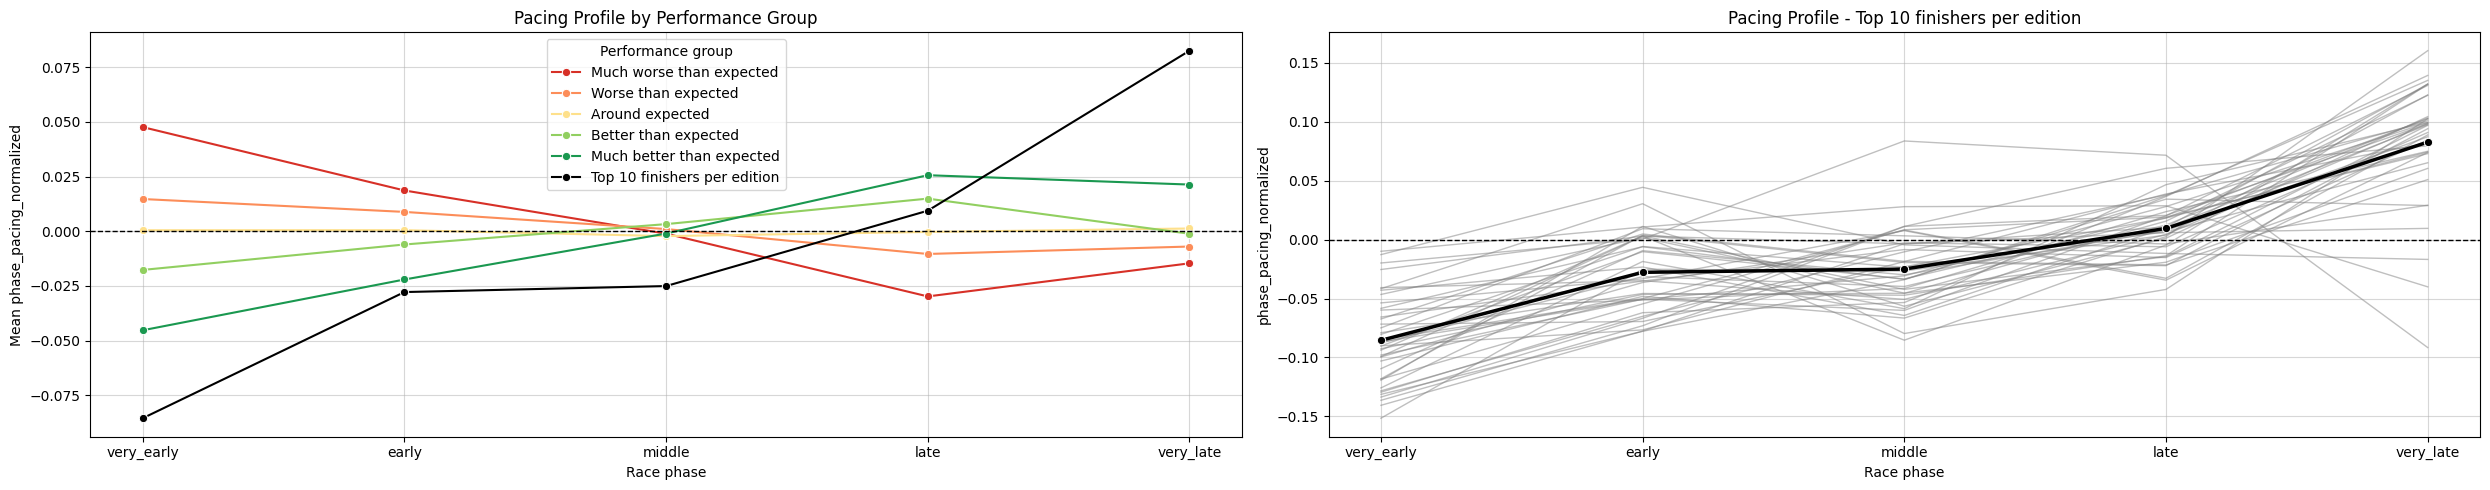

In [116]:
# Plot - Performance group x Race phase

fig, ax = plt.subplots(1, 2, figsize = (25, 5))

# 1. Race phase x Performance group
performance_group_palette = {
    "very_slow": "#d73027",
    "slow": "#fc8d59",
    "middle": "#fee08b",
    "fast": "#91cf60",
    "very_fast": "#1a9850",
    "absolute_top": "black",
}

performance_group_display_labels = {
    "very_slow": "Much worse than expected",
    "slow": "Worse than expected",
    "middle": "Around expected",
    "fast": "Better than expected",
    "very_fast": "Much better than expected",
    "absolute_top": "Top 10 finishers per edition",
}

performance_group_phase_pacing_summary_df = (
    performance_group_phase_pacing_summary_df
    .assign(
        runner_performance_group_label = lambda df: (
            df["runner_performance_group"].map(performance_group_display_labels)
        )
    )
)

sns.lineplot(
    data = performance_group_phase_pacing_summary_df, x = "race_phase", y = "phase_pacing_mean",
    hue = "runner_performance_group_label", 
    hue_order = [
        "Much worse than expected",
        "Worse than expected",
        "Around expected",
        "Better than expected",
        "Much better than expected",
        "Top 10 finishers per edition",
    ],
    palette = {
        "Much worse than expected": "#d73027",
        "Worse than expected": "#fc8d59",
        "Around expected": "#fee08b",
        "Better than expected": "#91cf60",
        "Much better than expected": "#1a9850",
        "Top 10 finishers per edition": "black",
    },
    marker = "o", linewidth = 1.5,
    ax = ax[0],
)
ax[0].axhline(0, color = "black", linestyle = "--", linewidth = 1)
ax[0].legend(title = "Performance group")
ax[0].set_title("Pacing Profile by Performance Group")
ax[0].set_xlabel("Race phase")
ax[0].set_ylabel("Mean phase_pacing_normalized")
ax[0].tick_params(axis = "x", rotation = 0)
ax[0].grid(alpha = 0.5)

# 2. Top performance runners - runner specific
absolute_top_runner_phase_pacing_df = (
    phase_pacing_analysis_df
    .query("runner_performance_group_top_absolute")
    .assign(
        runner_absolute_label = lambda df: df["year"].astype(str) + " | " + df["runner_id"].astype(str)
    )
)

sns.lineplot(
    data = absolute_top_runner_phase_pacing_df, x = "race_phase", y = "phase_pacing_normalized",
    units = "runner_absolute_label", estimator = None, color = "grey", linewidth = 1.0, alpha = 0.5,
    ax = ax[1],
)

sns.lineplot(
    data = absolute_top_runner_phase_pacing_df, x = "race_phase", y = "phase_pacing_normalized",
    estimator = "mean", errorbar = None, color = "black", marker = "o", linewidth = 2.5,
    ax = ax[1],
)

ax[1].axhline(0, color = "black", linestyle = "--", linewidth = 1)
ax[1].set_title("Pacing Profile - Top 10 finishers per edition")
ax[1].set_xlabel("Race phase")
ax[1].set_ylabel("phase_pacing_normalized")
ax[1].tick_params(axis = "x", rotation = 0)
ax[1].grid(alpha = 0.5)

# 2. Heatmap - How much of relative time does runner in each performance group spend in each race phase
# heatmap_df = (
#     performance_group_phase_pacing_summary_df
#     .pivot(
#         index = "runner_performance_group",
#         columns = "race_phase",
#         values = "phase_pacing_mean",
#     )
# )

# sns.heatmap(
#     heatmap_df,
#     annot = True,
#     fmt = ".3f",
#     center = 0,
#     cmap = "RdYlGn",
#     linewidths = 0.5,
#     ax = ax[1],
# )
# ax[1].set_title("Mean Normalized Pacing Heatmap")
# ax[1].set_xlabel("Race phase")
# ax[1].set_ylabel("Performance group")

plt.tight_layout()
plt.show()

# Very fast runners are negative early, positive late.
# Very slow runners are positive early, negative late.

Race peformance ~ Pacing
- Goal: Understand which pacing patterns are associated with better normalized race performance.
- Starting point: Engineer runner level pacing features (race phase based)

In [53]:
# Analysis df [runner_pacing_analysis_df] - pivot table so each runner is one row and race phases are columns

runner_pacing_analysis_df = (
    phase_pacing_analysis_df
    .pivot_table(
        index = [
            "race_id",
            "year",
            "runner_id",
            "runner_overall_index",
            "runner_race_time_normalized",
            "runner_rank_normalized",
        ],
        columns = "race_phase",
        values = "phase_pacing_normalized",
        observed = True,
    )
    .reset_index()
    .rename(columns={
        col: f"pacing_{col}" for col in ["very_early", "early", "middle", "late", "very_late"]
    })
    .sort_values("runner_id")
    .reset_index(drop=True)
)

In [54]:
# Engineer additional pacing features

phase_pacing_cols = [
    "pacing_very_early",
    "pacing_early",
    "pacing_middle",
    "pacing_late",
    "pacing_very_late",
]

phase_change_cols = [
    "pacing_change_very_early_to_early",
    "pacing_change_early_to_middle",
    "pacing_change_middle_to_late",
    "pacing_change_late_to_very_late",
]

runner_pacing_analysis_df = (
    runner_pacing_analysis_df
    .assign(
        # Start & finish
        pacing_start_score = lambda df: df["pacing_very_early"],
        pacing_finish_score = lambda df: df["pacing_very_late"],
        pacing_finish_vs_start_score = lambda df: (
            df["pacing_very_late"] - df["pacing_very_early"]
        ),

        # Late-race strength
        pacing_finish_kick_score = lambda df: (
            df["pacing_very_late"]
            - df[["pacing_very_early", "pacing_early", "pacing_middle", "pacing_late"]].mean(axis = 1)
        ),
        pacing_final_phase_kick_score = lambda df: (
            df["pacing_very_late"] - df["pacing_late"]
        ),
        pacing_late_strength_score = lambda df: (
            df[["pacing_late", "pacing_very_late"]].mean(axis = 1)
            - df[["pacing_very_early", "pacing_early"]].mean(axis = 1)
        ),

        # Early-race aggressiveness
        pacing_early_aggressiveness_score = lambda df: (
            df["pacing_very_early"]
            - df[["pacing_early", "pacing_middle", "pacing_late", "pacing_very_late"]].mean(axis = 1)
        ),

        # Middle-race shape
        pacing_middle_strength_score = lambda df: (
            df["pacing_middle"]
            - df[
                [
                    "pacing_very_early",
                    "pacing_early",
                    "pacing_late",
                    "pacing_very_late",
                ]
            ].mean(axis = 1)
        ),
        pacing_u_shape_score = lambda df: (
            df[["pacing_very_early", "pacing_very_late"]].mean(axis = 1)
            - df[["pacing_early", "pacing_middle", "pacing_late"]].mean(axis = 1)
        ),

        # Pacing stability
        pacing_variability_score = lambda df: df[phase_pacing_cols].std(axis = 1),
        pacing_range_score = lambda df: (
            df[phase_pacing_cols].max(axis = 1)
            - df[phase_pacing_cols].min(axis = 1)
        ),

        # Neighbor-to-neighbor changes
        pacing_change_very_early_to_early = lambda df: (
            df["pacing_early"] - df["pacing_very_early"]
        ),
        pacing_change_early_to_middle = lambda df: (
            df["pacing_middle"] - df["pacing_early"]
        ),
        pacing_change_middle_to_late = lambda df: (
            df["pacing_late"] - df["pacing_middle"]
        ),
        pacing_change_late_to_very_late = lambda df: (
            df["pacing_very_late"] - df["pacing_late"]
        ),
        pacing_stepwise_trend_score = lambda df: (
            df[phase_change_cols].mean(axis = 1)
        ),
        pacing_worst_phase_drop_score = lambda df: (
            df[phase_change_cols].min(axis = 1)
        ),
        pacing_best_phase_gain_score = lambda df: (
            df[phase_change_cols].max(axis = 1)
        ),

        # Overall pacing trend
        pacing_trend_score = lambda df: df[phase_pacing_cols].apply(
            lambda row: np.polyfit(
                np.array([0, 1, 2, 3, 4]),
                row.values.astype(float),
                deg = 1,
            )[0],
            axis = 1,
        ),

    )
)

# Best pacing template - Average pacing profile across all phases
best_runner_quantile = 3
best_runner_threshold = runner_pacing_analysis_df["runner_rank_normalized"].quantile(1 - best_runner_quantile/100)

best_pacing_template = (
    runner_pacing_analysis_df
    .query("runner_rank_normalized >= @best_runner_threshold")
    [phase_pacing_cols]
    .mean()
)

# pacing_similarity_to_best_profile_score
runner_pacing_analysis_df = (
    runner_pacing_analysis_df
    .assign(
        pacing_best_profile_distance  = lambda df: np.sqrt(
            ((df[phase_pacing_cols] - best_pacing_template) ** 2).sum(axis = 1)
        ),
        pacing_best_profile_score = lambda df: (
            1 / (1 + df["pacing_best_profile_distance"])
        ),
        pacing_best_profile_similarity_rank  = lambda df: (
            1 - df["pacing_best_profile_distance"].rank(pct = True)
        )
    )
)

- Core phase features - Higher = the runner spent less time than expected in the specific phase:
    - pacing_very_early
        - How relatively strong the runner was in the first 20% of the race.
    - pacing_early
        - How relatively strong the runner was between 20% and 40% of the race.
    - pacing_middle
        - How relatively strong the runner was in the middle part of the race.
    - pacing_late
        - How relatively strong the runner was between 60% and 80% of the race.
    - pacing_very_late
        - How relatively strong the runner was in the final 20% of the race.

- Start & finish:
    - pacing_start_score
        - How strong/aggressive the runner was at the start.
        - Higher = the runner started relatively faster than expected.
    - pacing_finish_score
        - How strong the runner was at the end.
        - Higher = the runner finished relatively faster than expected.
    - pacing_finish_vs_start_score
        - Captures whether the runner finished stronger than they started.
        - Higher = more negative split style / stronger finish relative to start.

- Late-race strength:
    - pacing_finish_kick_score
        - Captures whether the final phase was unusually strong compared with the rest of the race.
        - Higher = the runner had a strong final push.
    - pacing_final_phase_kick_score
        - Captures whether the runner improved specifically from the late phase into the very late phase.
        - Higher = clear final-phase acceleration.
    - pacing_late_strength_score
        - Captures whether the runner was stronger late than early.
        - Higher = better late-race durability.

- Early-race aggressiveness:
    - pacing_early_aggressiveness_score
        - Captures whether the runner invested too much effort very early compared with the rest of the race.
        - Higher = more aggressive opening phase.

- Middle-race shape:
    - pacing_middle_strength_score
        - Captures whether the runner had an unusually strong middle section.
        - Higher = middle phase stands out as strong compared with the rest of the race.
    - pacing_u_shape_score
        - Captures whether the runner was stronger at the beginning and end than in the middle.
        - Higher = more U-shaped pacing profile.

- Pacing stability:
    - pacing_variability_score
        - How uneven the runner’s pacing profile was across phases.
        - Higher = larger phase-to-phase differences.
    - pacing_range_score
        - Captures the gap between the runner’s strongest and weakest phase.
        - Higher = more extreme pacing variation.

- Neighbor-to-neighbor changes:
    - pacing_change_very_early_to_early
        - How much the runner changed after the opening phase.
        - Higher = the runner became relatively stronger from very early to early.
    - pacing_change_early_to_middle
        - Captures the transition from early race to middle race.
        - Higher = the runner became relatively stronger into the middle.
    - pacing_change_middle_to_late
        - Captures the transition from middle race to late race.
        - Higher = the runner became relatively stronger late.
    - pacing_change_late_to_very_late
        - Captures the transition from late race to final phase.
        - Higher = the runner became relatively stronger at the very end.
    - pacing_stepwise_trend_score
        - Captures the average direction of phase-to-phase changes.
        - Higher = pacing generally improved as the race progressed.
    - pacing_worst_phase_drop_score
        - Captures the runner’s biggest single fade between neighboring phases.
        - Lower/more negative = more severe fade.
    - pacing_best_phase_gain_score
        - Captures the runner’s biggest single improvement between neighboring phases.
        - Higher = stronger recovery or surge.

- Overall pacing trend:
    - pacing_trend_score
        - Captures the overall direction of the pacing profile from start to finish.
        - Higher = the runner became relatively stronger later in the race.
        - Lower/negative = the runner faded through the race.

- Best-profile similarity features:
    - Useful as descriptive or validation features, not as core explanatory features - do not explain the answer we are looking for.
    - They show whether the manually observed best-runner pacing pattern is actually associated with better normalized race performance.
    - How close was the runner to a profile we already know is good?

In [55]:
# About Pacing features

pacing_feature_groups = {

    "Individual phase scores": [
        ("Very early", "pacing_very_early"),
        ("Early", "pacing_early"),
        ("Middle", "pacing_middle"),
        ("Late", "pacing_late"),
        ("Very late", "pacing_very_late"),
    ],

    "Shape scores": [
        ("Finish vs start", "pacing_finish_vs_start_score"),
        ("Finish kick", "pacing_finish_kick_score"),
        ("Final phase kick", "pacing_final_phase_kick_score"),
        ("Late strength", "pacing_late_strength_score"),
        ("Early aggressiveness", "pacing_early_aggressiveness_score"),
        ("Middle strength", "pacing_middle_strength_score"),
        ("U-shape", "pacing_u_shape_score"),
    ],

    "Stability scores": [
        ("Variability", "pacing_variability_score"),
        ("Range", "pacing_range_score"),
    ],

    "Neighbor changes": [
        ("Very early to early", "pacing_change_very_early_to_early"),
        ("Early to middle", "pacing_change_early_to_middle"),
        ("Middle to late", "pacing_change_middle_to_late"),
        ("Late to very late", "pacing_change_late_to_very_late"),
        ("Stepwise trend", "pacing_stepwise_trend_score"),
        ("Worst phase drop", "pacing_worst_phase_drop_score"),
        ("Best phase gain", "pacing_best_phase_gain_score"),
    ],

    "Overall trend": [
        ("Trend", "pacing_trend_score"),
    ],

    "Optimal pacing similarity": [
        ("Best profile distance", "pacing_best_profile_distance"),
        ("Best profile score", "pacing_best_profile_score"),
        ("Best profile similarity rank", "pacing_best_profile_similarity_rank"),
    ],
}

# About
for group_name, features in pacing_feature_groups.items():
    print(f"\n{group_name}")
    for feature_name, feature_col in features:
        print(" - {} ({})".format(feature_name, feature_col))

# Save pacing features
pacing_feature_cols = []
for group_name, features in pacing_feature_groups.items():
    # print(f"\n# {group_name}")
    for feature_name, feature_col in features:
        # print(" - {} ({})".format(feature_name, feature_col))
        pacing_feature_cols.append(feature_col)


Individual phase scores
 - Very early (pacing_very_early)
 - Early (pacing_early)
 - Middle (pacing_middle)
 - Late (pacing_late)
 - Very late (pacing_very_late)

Shape scores
 - Finish vs start (pacing_finish_vs_start_score)
 - Finish kick (pacing_finish_kick_score)
 - Final phase kick (pacing_final_phase_kick_score)
 - Late strength (pacing_late_strength_score)
 - Early aggressiveness (pacing_early_aggressiveness_score)
 - Middle strength (pacing_middle_strength_score)
 - U-shape (pacing_u_shape_score)

Stability scores
 - Variability (pacing_variability_score)
 - Range (pacing_range_score)

Neighbor changes
 - Very early to early (pacing_change_very_early_to_early)
 - Early to middle (pacing_change_early_to_middle)
 - Middle to late (pacing_change_middle_to_late)
 - Late to very late (pacing_change_late_to_very_late)
 - Stepwise trend (pacing_stepwise_trend_score)
 - Worst phase drop (pacing_worst_phase_drop_score)
 - Best phase gain (pacing_best_phase_gain_score)

Overall trend
 -

Identify strongest pacing signals and understand their direction ~ Univariate feature analysis

In [56]:
# Univariate analysis configuration
pacing_analysis_target_col = "runner_race_time_normalized"
pacing_analysis_target_col_name = "Normalized race time"

In [57]:
# Individual phase scores ~ "Turn on" printouts & plots

individual_phase_scores_univariate_summary_df = pd.DataFrame()
for feature_name, feature_col in pacing_feature_groups["Individual phase scores"]:

    summary_df = univariate_numeric_linear_analysis(
        feature_col = feature_col,
        target_col = pacing_analysis_target_col,
        df = runner_pacing_analysis_df,
        feature_col_name = feature_name,
        target_col_name = pacing_analysis_target_col_name,
        print_summary = False,
        plot = False,
        n_bins = 20,
    )

    individual_phase_scores_univariate_summary_df = pd.concat([individual_phase_scores_univariate_summary_df, summary_df], ignore_index=True)

display(
    individual_phase_scores_univariate_summary_df
    .sort_values(
        ["r2", "scaled_coef"], 
        ascending = False, 
        key=abs
    )
)

,feature_col,target_col,n_obs,intercept,coef,scaled_coef,p_value,r2
0,pacing_very_early,runner_race_time_normalized,6863,0.000319,-0.564086,-0.040910,0.000000e+00,0.210933
3,pacing_late,runner_race_time_normalized,6863,0.000305,0.535853,0.030997,1.365555e-194,0.121095
1,pacing_early,runner_race_time_normalized,6863,0.000318,-0.404130,-0.023011,4.732051e-105,0.066734
4,pacing_very_late,runner_race_time_normalized,6863,0.000322,0.180448,0.014538,3.524818e-42,0.026636
2,pacing_middle,runner_race_time_normalized,6863,0.000319,-0.011318,-0.000573,5.944696e-01,0.000041


runner_race_time_normalized ~ pacing_finish_vs_start_score:
 - number of observations: 6,863
 - intercept: 0.000323
 - coefficient: 0.248580
 - scaled coefficient: 0.032073
 - p-value: 0.000000
 - R2: 0.129646


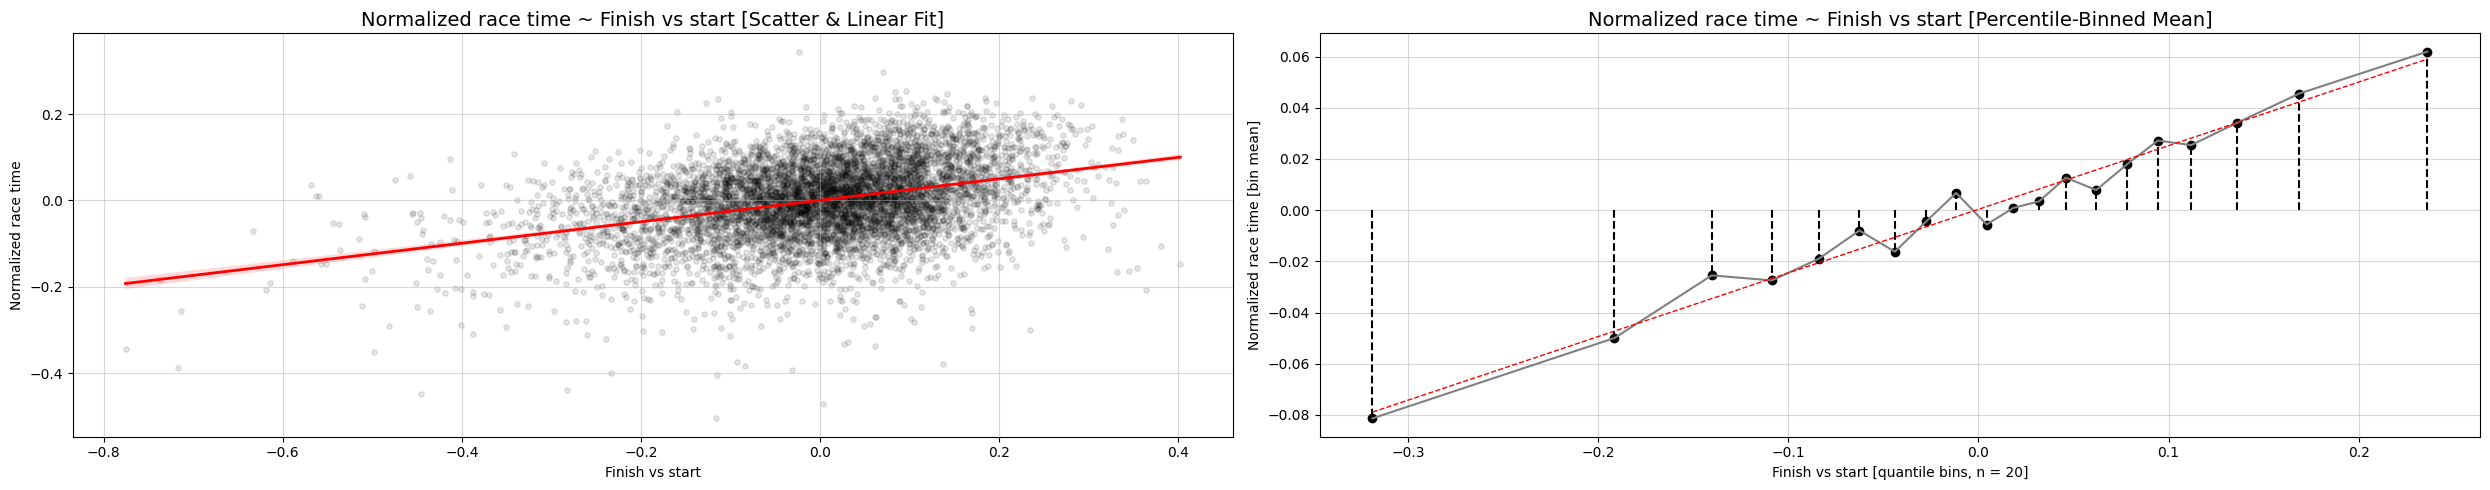

runner_race_time_normalized ~ pacing_finish_kick_score:
 - number of observations: 6,863
 - intercept: 0.000322
 - coefficient: 0.155335
 - scaled coefficient: 0.016719
 - p-value: 0.000000
 - R2: 0.035229


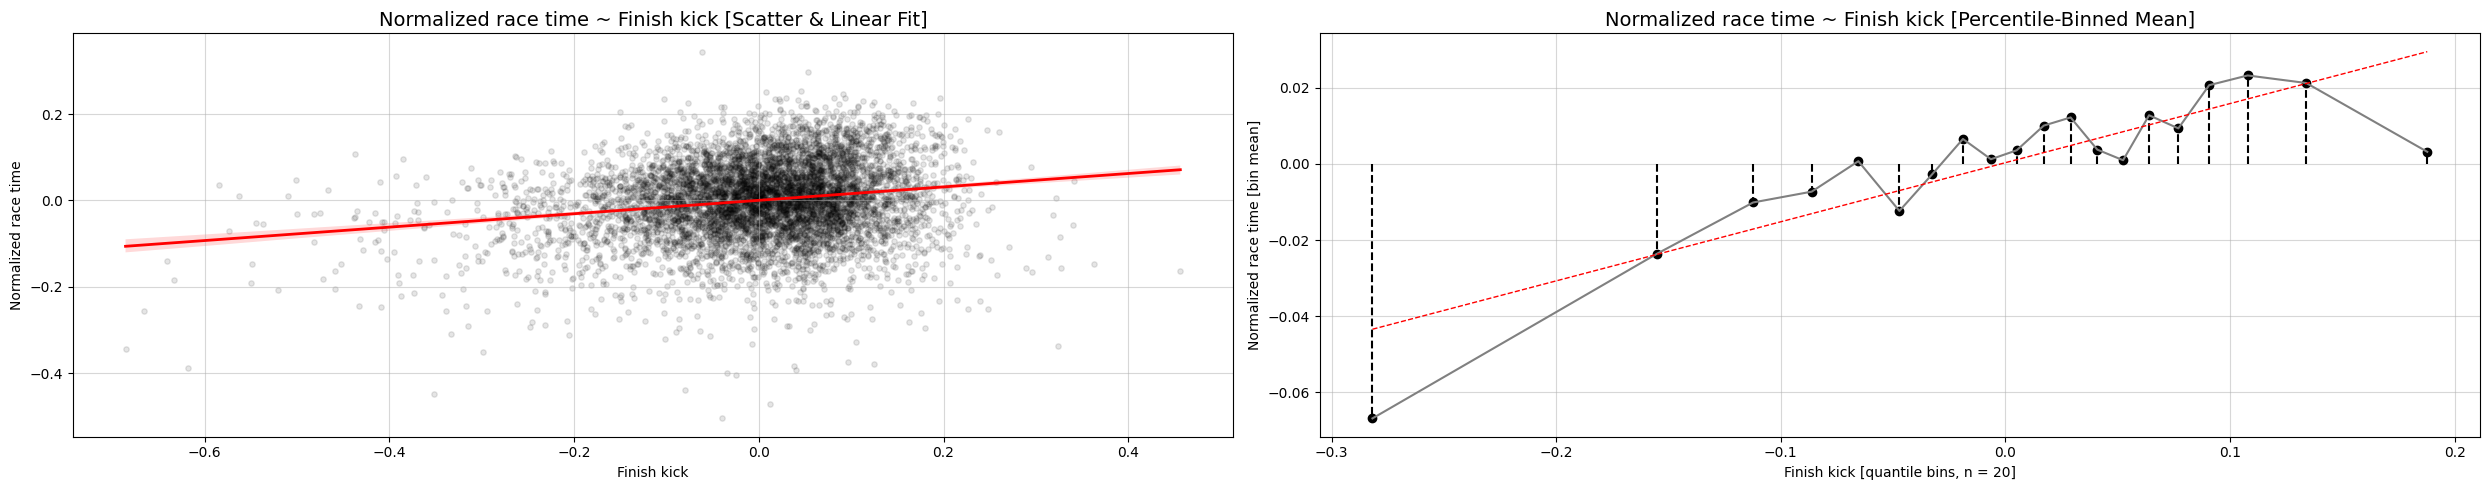

runner_race_time_normalized ~ pacing_final_phase_kick_score:
 - number of observations: 6,863
 - intercept: 0.000317
 - coefficient: -0.053084
 - scaled coefficient: -0.005746
 - p-value: 0.000000
 - R2: 0.004160


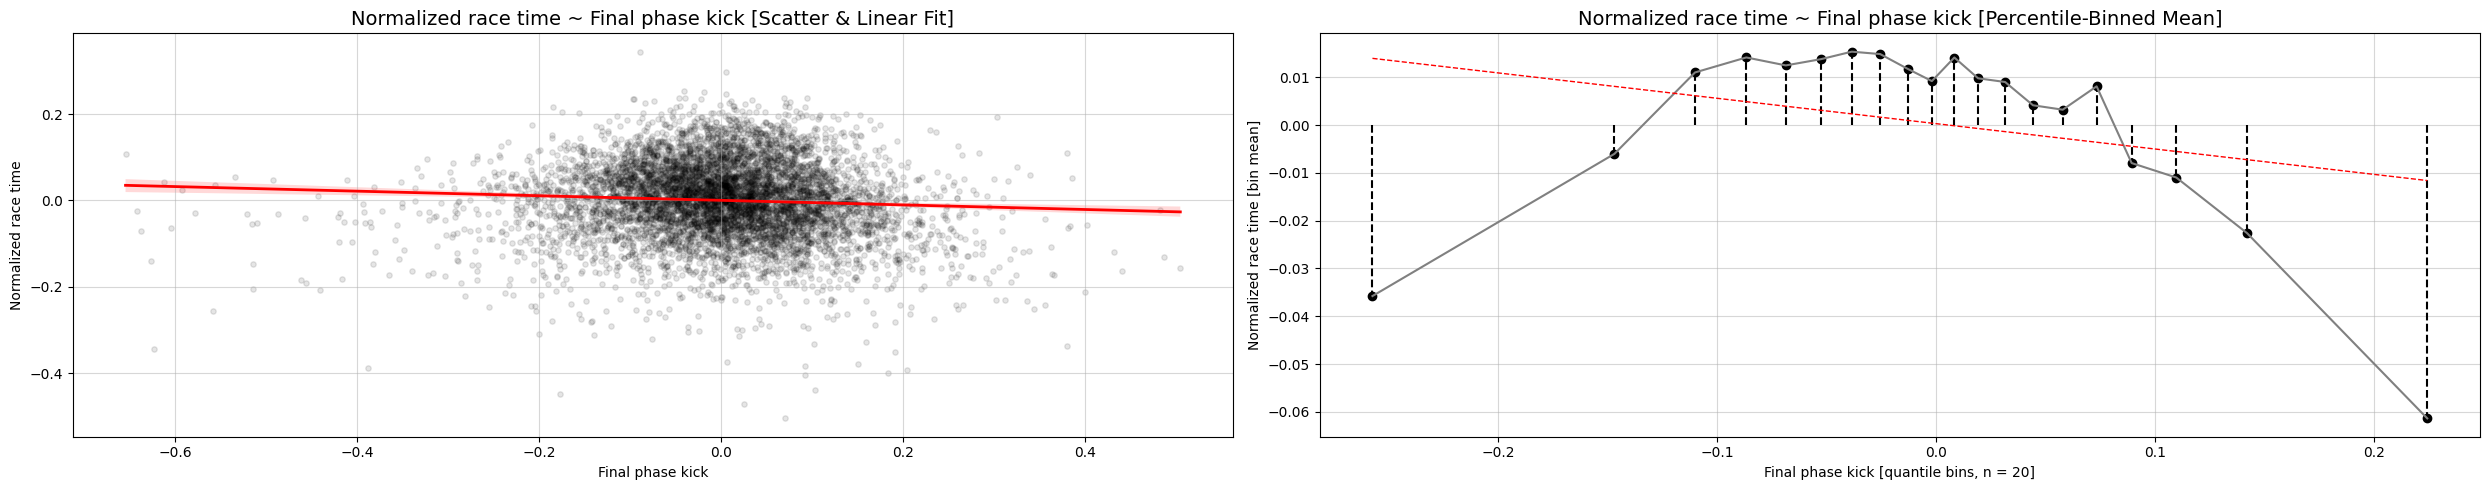

runner_race_time_normalized ~ pacing_late_strength_score:
 - number of observations: 6,863
 - intercept: 0.000316
 - coefficient: 0.406543
 - scaled coefficient: 0.038366
 - p-value: 0.000000
 - R2: 0.185518


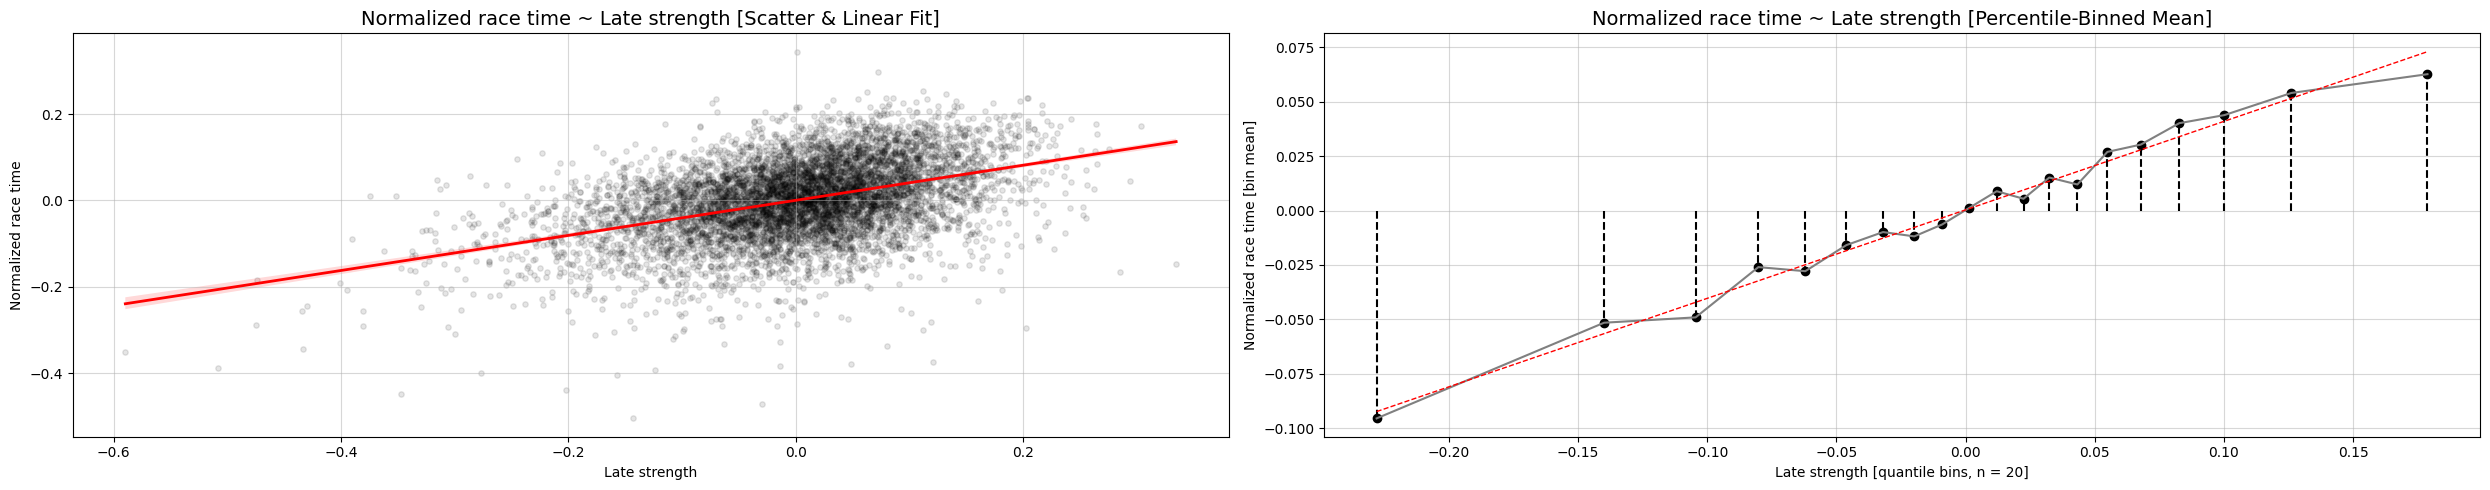

runner_race_time_normalized ~ pacing_early_aggressiveness_score:
 - number of observations: 6,863
 - intercept: 0.000318
 - coefficient: -0.503084
 - scaled coefficient: -0.041195
 - p-value: 0.000000
 - R2: 0.213882


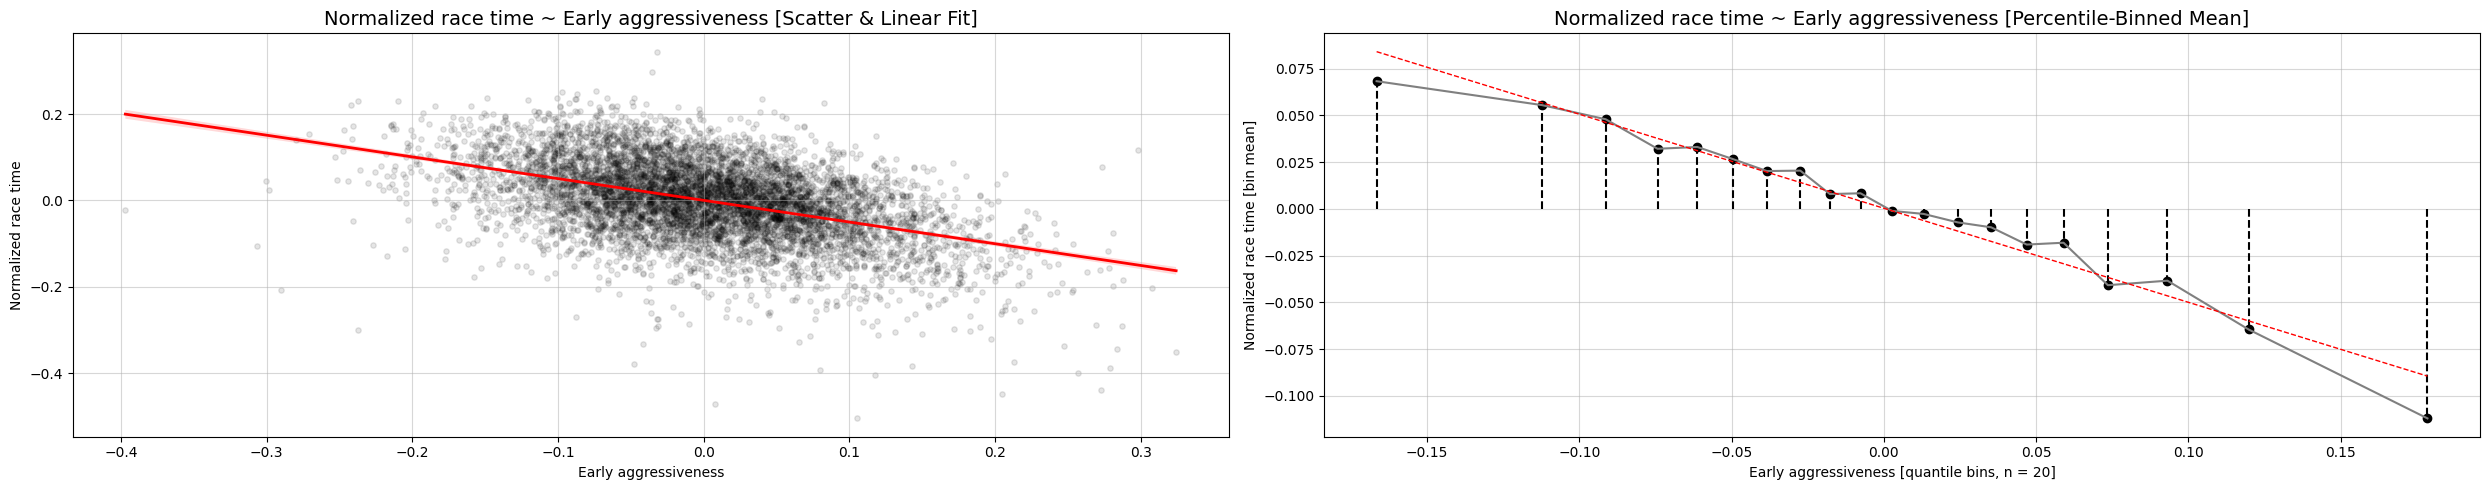

runner_race_time_normalized ~ pacing_middle_strength_score:
 - number of observations: 6,863
 - intercept: 0.000319
 - coefficient: 0.076658
 - scaled coefficient: 0.004790
 - p-value: 0.000008
 - R2: 0.002891


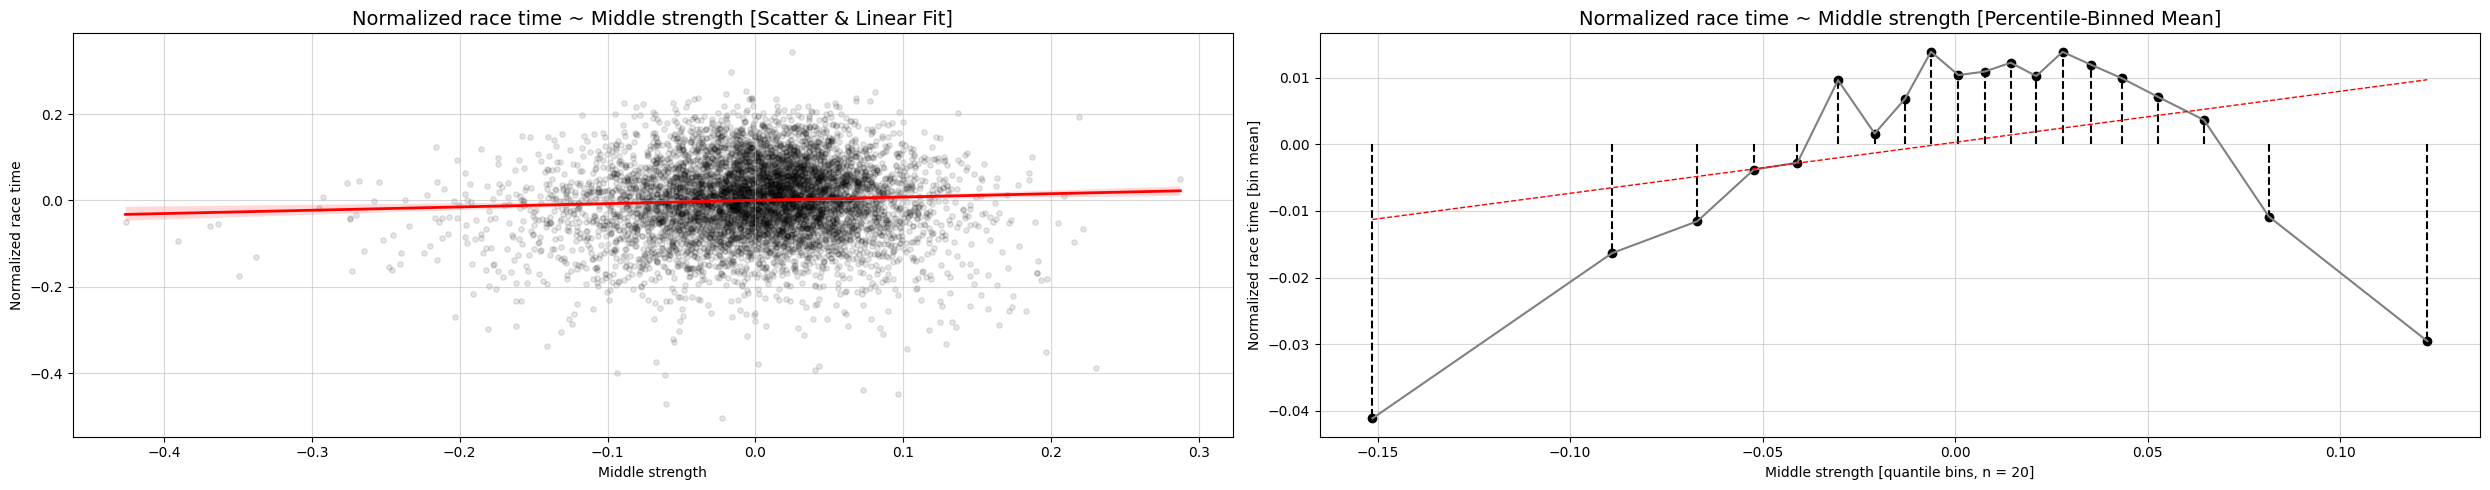

runner_race_time_normalized ~ pacing_u_shape_score:
 - number of observations: 6,863
 - intercept: 0.000315
 - coefficient: -0.223385
 - scaled coefficient: -0.015309
 - p-value: 0.000000
 - R2: 0.029539


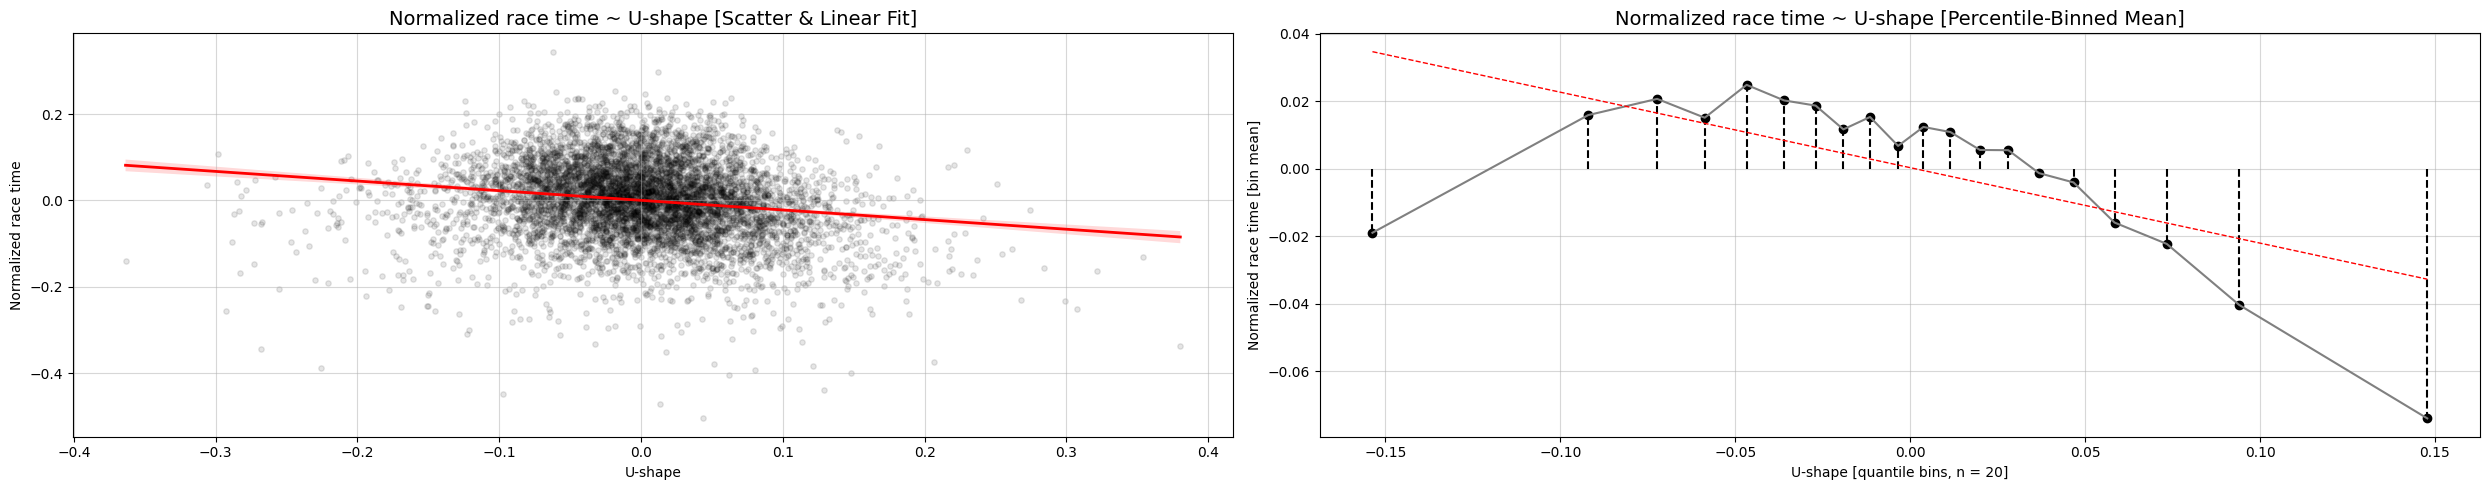

,feature_col,target_col,n_obs,intercept,coef,scaled_coef,p_value,r2
4,pacing_early_aggressiveness_score,runner_race_time_normalized,6863,0.000318,-0.503084,-0.041195,0.000000e+00,0.213882
3,pacing_late_strength_score,runner_race_time_normalized,6863,0.000316,0.406543,0.038366,4.244067e-308,0.185518
0,pacing_finish_vs_start_score,runner_race_time_normalized,6863,0.000323,0.248580,0.032073,3.576238e-209,0.129646
1,pacing_finish_kick_score,runner_race_time_normalized,6863,0.000322,0.155335,0.016719,1.888158e-55,0.035229
6,pacing_u_shape_score,runner_race_time_normalized,6863,0.000315,-0.223385,-0.015309,1.188678e-46,0.029539
2,pacing_final_phase_kick_score,runner_race_time_normalized,6863,0.000317,-0.053084,-0.005746,8.886693e-08,0.004160
5,pacing_middle_strength_score,runner_race_time_normalized,6863,0.000319,0.076658,0.004790,8.310388e-06,0.002891


In [129]:
# Shape scores ~ "Turn on" printouts & plots
shape_scores_univariate_summary_df = pd.DataFrame()
for feature_name, feature_col in pacing_feature_groups["Shape scores"]:

    summary_df = univariate_numeric_linear_analysis(
        feature_col = feature_col,
        target_col = pacing_analysis_target_col,
        df = runner_pacing_analysis_df,
        feature_col_name = feature_name,
        target_col_name = pacing_analysis_target_col_name,
        print_summary = True,
        plot = True,
        n_bins = 20,
    )

    shape_scores_univariate_summary_df = pd.concat([shape_scores_univariate_summary_df, summary_df], ignore_index=True)

display(
    shape_scores_univariate_summary_df
    .sort_values(
        ["r2", "scaled_coef"], 
        ascending = False, 
        key=abs
    )
)

In [59]:
# Stability scores ~ "Turn on" printouts & plots
stability_scores_univariate_summary_df = pd.DataFrame()
for feature_name, feature_col in pacing_feature_groups["Stability scores"]:

    summary_df = univariate_numeric_linear_analysis(
        feature_col = feature_col,
        target_col = pacing_analysis_target_col,
        df = runner_pacing_analysis_df,
        feature_col_name = feature_name,
        target_col_name = pacing_analysis_target_col_name,
        print_summary = False,
        plot = False,
        n_bins = 20,
    )

    stability_scores_univariate_summary_df = pd.concat([stability_scores_univariate_summary_df, summary_df], ignore_index=True)

display(
    stability_scores_univariate_summary_df
    .sort_values(
        ["r2", "scaled_coef"], 
        ascending = False, 
        key=abs
    )
)

,feature_col,target_col,n_obs,intercept,coef,scaled_coef,p_value,r2
0,pacing_variability_score,runner_race_time_normalized,6863,0.038721,-0.606705,-0.020477,5.356537e-83,0.052848
1,pacing_range_score,runner_race_time_normalized,6863,0.037801,-0.239756,-0.020004,3.415594e-79,0.050433


In [127]:
# Neighbor changes ~ "Turn on" printouts & plots
neighbor_changes_univariate_summary_df = pd.DataFrame()
for feature_name, feature_col in pacing_feature_groups["Neighbor changes"]:

    summary_df = univariate_numeric_linear_analysis(
        feature_col = feature_col,
        target_col = pacing_analysis_target_col,
        df = runner_pacing_analysis_df,
        feature_col_name = feature_name,
        target_col_name = pacing_analysis_target_col_name,
        print_summary = False,
        plot = False,
        n_bins = 20,
    )

    neighbor_changes_univariate_summary_df = pd.concat([neighbor_changes_univariate_summary_df, summary_df], ignore_index=True)

display(
    neighbor_changes_univariate_summary_df
    .sort_values(
        ["r2", "scaled_coef"], 
        ascending = False, 
        key=abs
    )
)

,feature_col,target_col,n_obs,intercept,coef,scaled_coef,p_value,r2
4,pacing_stepwise_trend_score,runner_race_time_normalized,6863,0.000323,0.994319,0.032073,3.576238e-209,0.129646
5,pacing_worst_phase_drop_score,runner_race_time_normalized,6863,0.035995,0.404383,0.029863,6.674352e-180,0.112396
2,pacing_change_middle_to_late,runner_race_time_normalized,6863,0.000312,0.307180,0.023658,3.762945e-111,0.070539
0,pacing_change_very_early_to_early,runner_race_time_normalized,6863,0.000319,0.307055,0.022555,7.188452e-101,0.064116
1,pacing_change_early_to_middle,runner_race_time_normalized,6863,0.000318,0.248629,0.017848,4.282421e-63,0.040148
3,pacing_change_late_to_very_late,runner_race_time_normalized,6863,0.000317,-0.053084,-0.005746,8.886693e-08,0.004160
6,pacing_best_phase_gain_score,runner_race_time_normalized,6863,0.004700,-0.051792,-0.003111,3.809866e-03,0.001220


In [61]:
# Overall trend ~ "Turn on" printouts & plots
overall_trend_univariate_summary_df = pd.DataFrame()
for feature_name, feature_col in pacing_feature_groups["Overall trend"]:

    summary_df = univariate_numeric_linear_analysis(
        feature_col = feature_col,
        target_col = pacing_analysis_target_col,
        df = runner_pacing_analysis_df,
        feature_col_name = feature_name,
        target_col_name = pacing_analysis_target_col_name,
        print_summary = False,
        plot = False,
        n_bins = 20,
    )

    overall_trend_univariate_summary_df = pd.concat([overall_trend_univariate_summary_df, summary_df], ignore_index=True)

display(
    overall_trend_univariate_summary_df
    .sort_values(
        ["r2", "scaled_coef"], 
        ascending = False, 
        key=abs
    )
)

,feature_col,target_col,n_obs,intercept,coef,scaled_coef,p_value,r2
0,pacing_trend_score,runner_race_time_normalized,6863,0.000319,1.18842,0.036775,9.272497e-281,0.170444


In [62]:
# Optimal pacing similarity ~ "Turn on" printouts & plots
optimal_pacing_similarity_univariate_summary_df = pd.DataFrame()
for feature_name, feature_col in pacing_feature_groups["Optimal pacing similarity"]:

    summary_df = univariate_numeric_linear_analysis(
        feature_col = feature_col,
        target_col = pacing_analysis_target_col,
        df = runner_pacing_analysis_df,
        feature_col_name = feature_name,
        target_col_name = pacing_analysis_target_col_name,
        print_summary = False,
        plot = False,
        n_bins = 20,
    )

    optimal_pacing_similarity_univariate_summary_df = pd.concat([optimal_pacing_similarity_univariate_summary_df, summary_df], ignore_index=True)

display(
    optimal_pacing_similarity_univariate_summary_df
    .sort_values(
        ["r2", "scaled_coef"], 
        ascending = False, 
        key=abs
    )
)

,feature_col,target_col,n_obs,intercept,coef,scaled_coef,p_value,r2
1,pacing_best_profile_score,runner_race_time_normalized,6863,-0.587521,0.673715,0.039082,0.000000e+00,0.192502
0,pacing_best_profile_distance,runner_race_time_normalized,6863,0.071423,-0.469167,-0.038858,0.000000e+00,0.190301
2,pacing_best_profile_similarity_rank,runner_race_time_normalized,6863,-0.064461,0.129578,0.037409,1.890862e-291,0.176372


In [63]:
# Overall Summary
univariate_summary_features_df = pd.concat([
    individual_phase_scores_univariate_summary_df,
    shape_scores_univariate_summary_df,
    stability_scores_univariate_summary_df,
    neighbor_changes_univariate_summary_df,
    overall_trend_univariate_summary_df,
    optimal_pacing_similarity_univariate_summary_df
], ignore_index=True)


display(
    univariate_summary_features_df
    .sort_values(
        ["r2", "scaled_coef"], 
        ascending = False, 
        key=abs
    )
)

,feature_col,target_col,n_obs,intercept,coef,scaled_coef,p_value,r2
9,pacing_early_aggressiveness_score,runner_race_time_normalized,6863,0.000318,-0.503084,-0.041195,0.000000e+00,0.213882
0,pacing_very_early,runner_race_time_normalized,6863,0.000319,-0.564086,-0.040910,0.000000e+00,0.210933
23,pacing_best_profile_score,runner_race_time_normalized,6863,-0.587521,0.673715,0.039082,0.000000e+00,0.192502
22,pacing_best_profile_distance,runner_race_time_normalized,6863,0.071423,-0.469167,-0.038858,0.000000e+00,0.190301
8,pacing_late_strength_score,runner_race_time_normalized,6863,0.000316,0.406543,0.038366,4.244067e-308,0.185518
24,pacing_best_profile_similarity_rank,runner_race_time_normalized,6863,-0.064461,0.129578,0.037409,1.890862e-291,0.176372
21,pacing_trend_score,runner_race_time_normalized,6863,0.000319,1.188420,0.036775,9.272497e-281,0.170444
5,pacing_finish_vs_start_score,runner_race_time_normalized,6863,0.000323,0.248580,0.032073,3.576238e-209,0.129646
18,pacing_stepwise_trend_score,runner_race_time_normalized,6863,0.000323,0.994319,0.032073,3.576238e-209,0.129646
3,pacing_late,runner_race_time_normalized,6863,0.000305,0.535853,0.030997,1.365555e-194,0.121095


About ~ Univariate feature analysis

- Strongest feature(s): 
    - pacing_early_aggressiveness_score, pacing_very_early.
    - Negative coefficients - runners who are relatively too fast in the very early phase tend to have worse normalized race performance.
    - Started too hot, paid later

- Early pacing features
    - Explain performance better than best-profile similarity features.
    - Opening phase contains a lot of information about the final outcome.
        - Too aggresive start creates damage that is hard to repair later.
        - Runners who start more controlled are more likely to keep moving well later.
        - The rest of the pacing profile is a strong consequence of the opening decision.
    - Early pacing may be the strongest single warning signal - Avoid being too aggressive in the first part of the race.

- Late strength features
    - Runners who become relatively stronger later tend to perform better.
    - Positive coefficients - runners who are relatively fast in the late phase tend to have better normalized race performance.

- Middle pacing alone explains almost nothing.

- Final kick alone is weak.
  - The last-phase improvement alone does not explain much compared with the whole pacing trend.

- Pacing variability/range has a moderate relationship with performance.
    - Weaker than early aggressiveness and late strength

- Main finding: 
    - The strongest signal is not "finish fast". It is "do not be too aggressive very early".
    - Best performes are runners who avoid being too aggressive very early and maintain or improve their relative pacing later in the race.

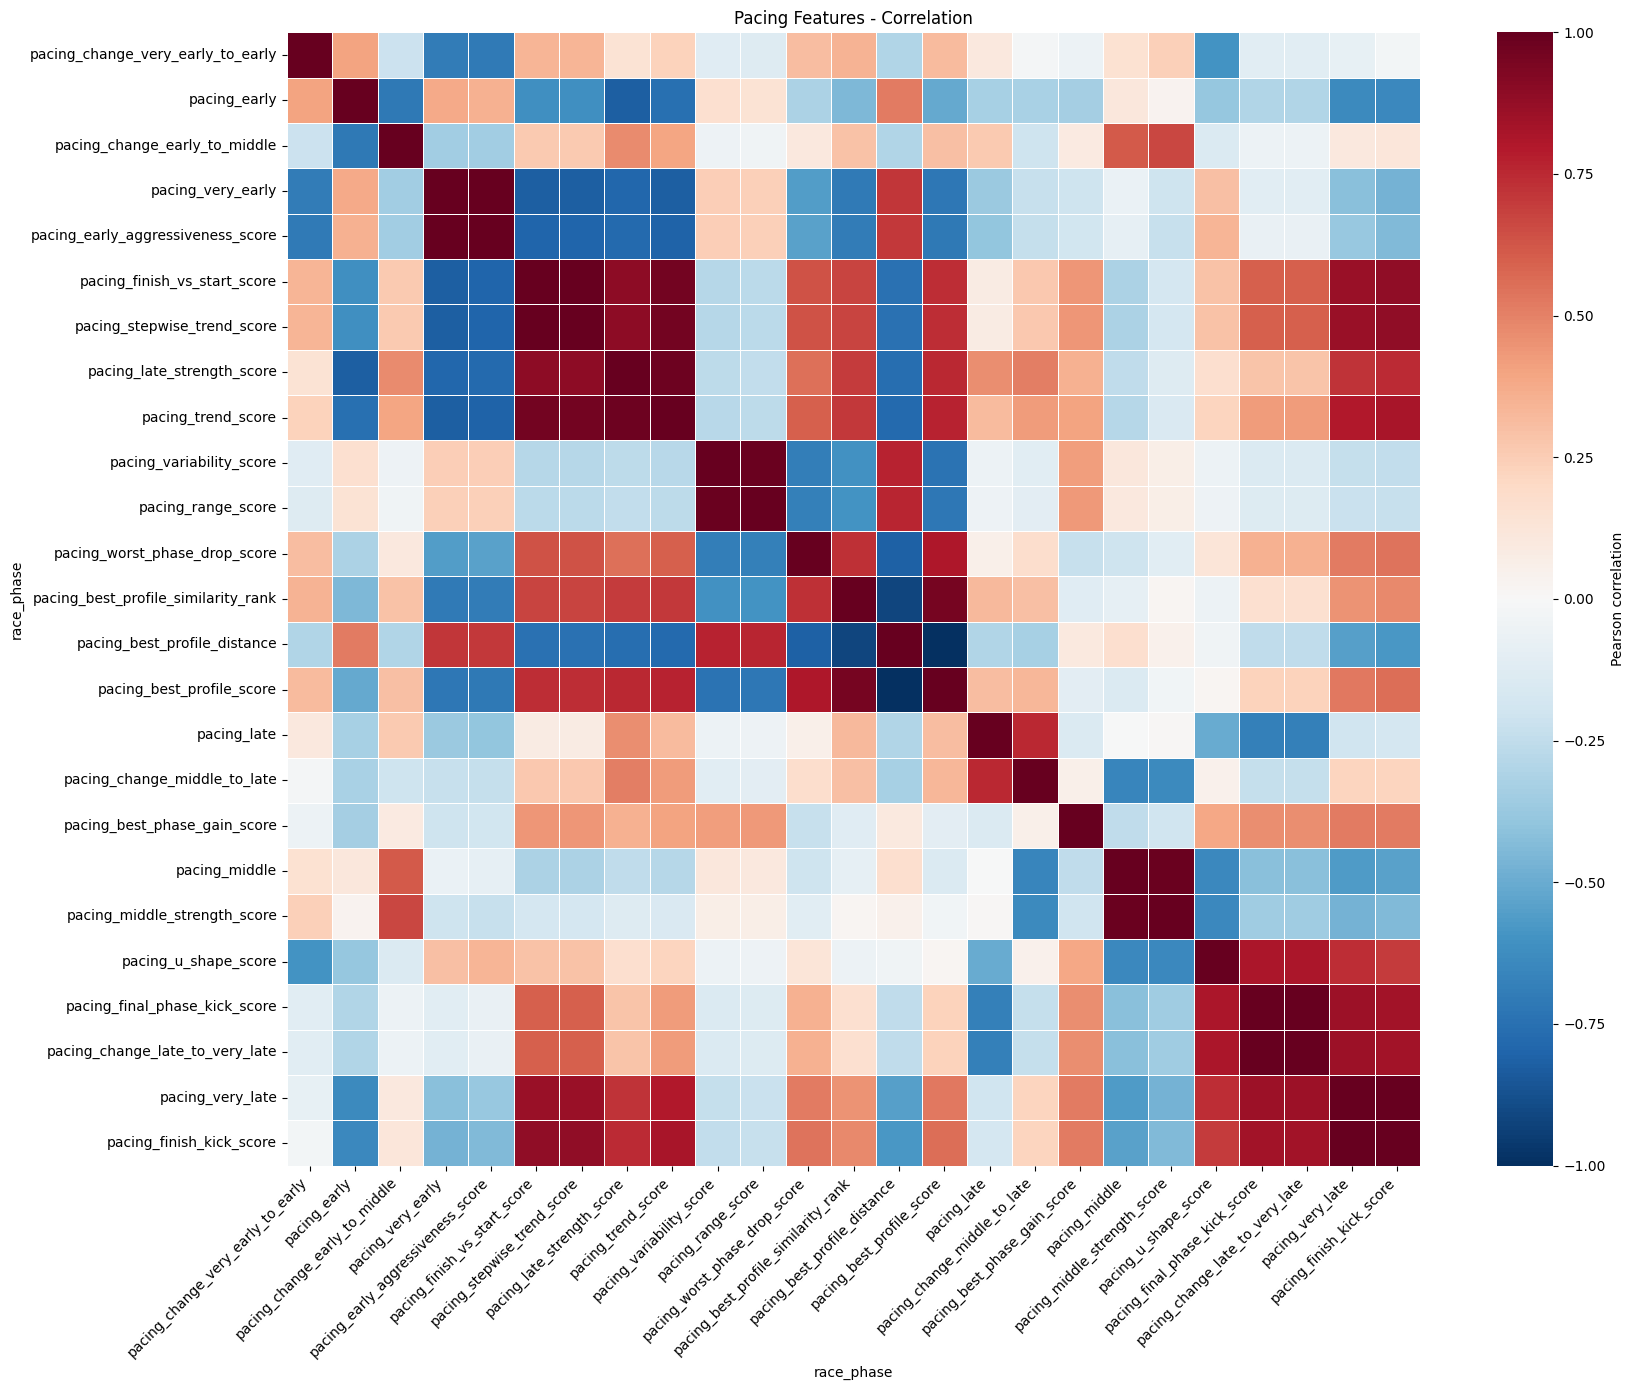

In [64]:
# Features correlation (clustered by correlation similarity)
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# Compute correlations and cluster by correlation similarity
corr = runner_pacing_analysis_df[pacing_feature_cols].corr()
corr_distance = 1 - corr.abs()
corr_cluster = linkage(
    squareform(corr_distance, checks = False),
    method = "average",
)

# Reorder correlation matrix
ordered_features = corr.columns[leaves_list(corr_cluster)]
corr_ordered = corr.loc[ordered_features, ordered_features]

# Plot heatmap
plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_ordered,
    cmap = "RdBu_r",
    center = 0,
    vmin = -1,
    vmax = 1,
    square = True,
    linewidths = 0.4,
    cbar_kws = {"label": "Pearson correlation"},
)

plt.title("Pacing Features - Correlation")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Correlation notes:

- Note:
    - Many pacing features describe the same underlying pacing shape from different angles. 
    - We should not interpret them as fully independent.

- Early & Late pacing:
    - Strong early pacing is usually connected with weaker late pacing (fading).
    - If a runner is stronger late than early, then their overall pacing trend will usually also be positive.

- Similar features - did the runner become relatively stronger or weaker as the race progressed?
    - finish-vs-start
    - late-strength
    - stepwise-trend

- How even the pacing profile is:
    - Pacing variability 
    - Pacing range

- Pacing trend.
    - Neighbor-to-neighbor
    - Trend features

- Findings:
    - Pacing strategy is mostly one broad axis.
    - Aggressive start and weaker finish vs. controlled start and stronger finish.

In [65]:
# Helper function - selected feature most strong correlated

def get_strongly_correlated_features(
        feature_col: str,
        correlation_df: pd.DataFrame,
        threshold: float = 0.70,
    ) -> pd.DataFrame:
    
    correlated_features_df = (
        correlation_df[feature_col]
        .drop(labels = [feature_col])
        .reset_index()
        .rename(columns={
            "index": "feature_col",
            feature_col: "correlation",
        })
        .assign(
            abs_correlation = lambda df: df["correlation"].abs(),
            recommendation = lambda df: np.where(
                df["abs_correlation"] >= threshold,
                "avoid_together",
                "ok",
            ),
        )
        .query("abs_correlation >= @threshold")
        .sort_values("abs_correlation", ascending = False)
        .reset_index(drop = True)
    )

    return correlated_features_df

def display_strongly_correlated_features(
        feature_col: str,
        correlation_df: pd.DataFrame,
        threshold: float = 0.70,
    ) -> pd.DataFrame:

    correlated_features_df = get_strongly_correlated_features(
        feature_col = feature_col,
        correlation_df = correlation_df,
        threshold = threshold,
    )

    print(f"Selected feature: {feature_col}")
    print(f"Correlation threshold: {threshold}")

    if correlated_features_df.empty:
        print("No strongly correlated features found.")
    else:
        print("Avoid choosing these together with selected feature:")

    display(correlated_features_df)

    return correlated_features_df

Mulativariate analysis

- Univariate story:
    - Too aggressive early = worse
    - Stronger late trend = better

- Multivariate goal:
    - Is late strength really important by itself, or does it only look important because it is the opposite of starting too fast?
    - Find the simplest explanation - one or two features may explain almost the same thing as ten separate univariate features.
    - Helps us understand whether early pacing explains almost everything, or whether late strength, pacing stability, and trend still add information beyond the start.
    - Simplify the story.

- Multivariate model check:
    - Find a small, interpretable set of pacing features that explains the main pacing-performance relationship.
    - It has reasonable explanatory power.
    - The coefficients make sense directionally.
    - It improves over simple one-feature models.

In [73]:
# Helper - Check which features to try in the model
tmp = display_strongly_correlated_features(
        feature_col = "pacing_early_aggressiveness_score",
        correlation_df = corr_ordered,
        threshold = 0.75,
    )

Selected feature: pacing_early_aggressiveness_score
Correlation threshold: 0.75
Avoid choosing these together with selected feature:


,race_phase,correlation,abs_correlation,recommendation
0,pacing_very_early,0.998592,0.998592,avoid_together
1,pacing_trend_score,-0.806837,0.806837,avoid_together
2,pacing_finish_vs_start_score,-0.800068,0.800068,avoid_together
3,pacing_stepwise_trend_score,-0.800068,0.800068,avoid_together
4,pacing_late_strength_score,-0.775867,0.775867,avoid_together


In [ ]:
# Final interpretable pacing model

# Prepare data
pacing_model_feature_cols = [
    "pacing_early_aggressiveness_score",
    "pacing_late_strength_score",
    "pacing_variability_score",
]

df_pacing_model = (
    runner_pacing_analysis_df
    [["runner_race_time_normalized"] + pacing_model_feature_cols]
    .dropna()
    .copy()
)

# Fit & Predict
X_pacing_model = sm.add_constant(df_pacing_model[pacing_model_feature_cols])
y_pacing_model = df_pacing_model["runner_race_time_normalized"]

model_pacing = sm.OLS(y_pacing_model, X_pacing_model)
fit_pacing = model_pacing.fit()

runner_race_time_normalized_pred = fit_pacing.predict(sm.add_constant(df_pacing_model[pacing_model_feature_cols]))

df_pacing_model = (
    df_pacing_model
    .assign(
        runner_race_time_normalized_pred = runner_race_time_normalized_pred,
        runner_race_time_normalized_residual = lambda df: (
            df["runner_race_time_normalized"]
            - df["runner_race_time_normalized_pred"]
        ),
    )
)

In [83]:
# Coefficients

coef_pacing_model_df = (
    pd.DataFrame({
        "coef": fit_pacing.params,
        "std_err": fit_pacing.bse,
        "p_value": fit_pacing.pvalues,
        "ci_lower": fit_pacing.conf_int()[0],
        "ci_upper": fit_pacing.conf_int()[1],
    })
    .reset_index(names = "term")
    .assign(abs_coef = lambda df: df["coef"].abs())
    .sort_values("abs_coef", ascending = False)
    .reset_index(drop = True)
)

print("Full pacing model")
print("------------------------------------")
print(f"R-squared: {fit_pacing.rsquared:.4f}")
print(f"Adjusted R-squared: {fit_pacing.rsquared_adj:.4f}")
print(f"Number of observations: {int(fit_pacing.nobs):,}")

display(
    coef_pacing_model_df
    .sort_values("p_value")
)

Full pacing model
------------------------------------
R-squared: 0.2385
Adjusted R-squared: 0.2382
Number of observations: 6,863


,term,coef,std_err,p_value,ci_lower,ci_upper,abs_coef
0,pacing_early_aggressiveness_score,-0.337748,0.018211,5.813204e-75,-0.373447,-0.302048,0.337748
1,pacing_variability_score,-0.295677,0.028875,1.970399e-24,-0.352281,-0.239072,0.295677
2,pacing_late_strength_score,0.151568,0.015872,1.770921e-21,0.120454,0.182681,0.151568
3,const,0.019032,0.002055,2.600991e-20,0.015005,0.023060,0.019032


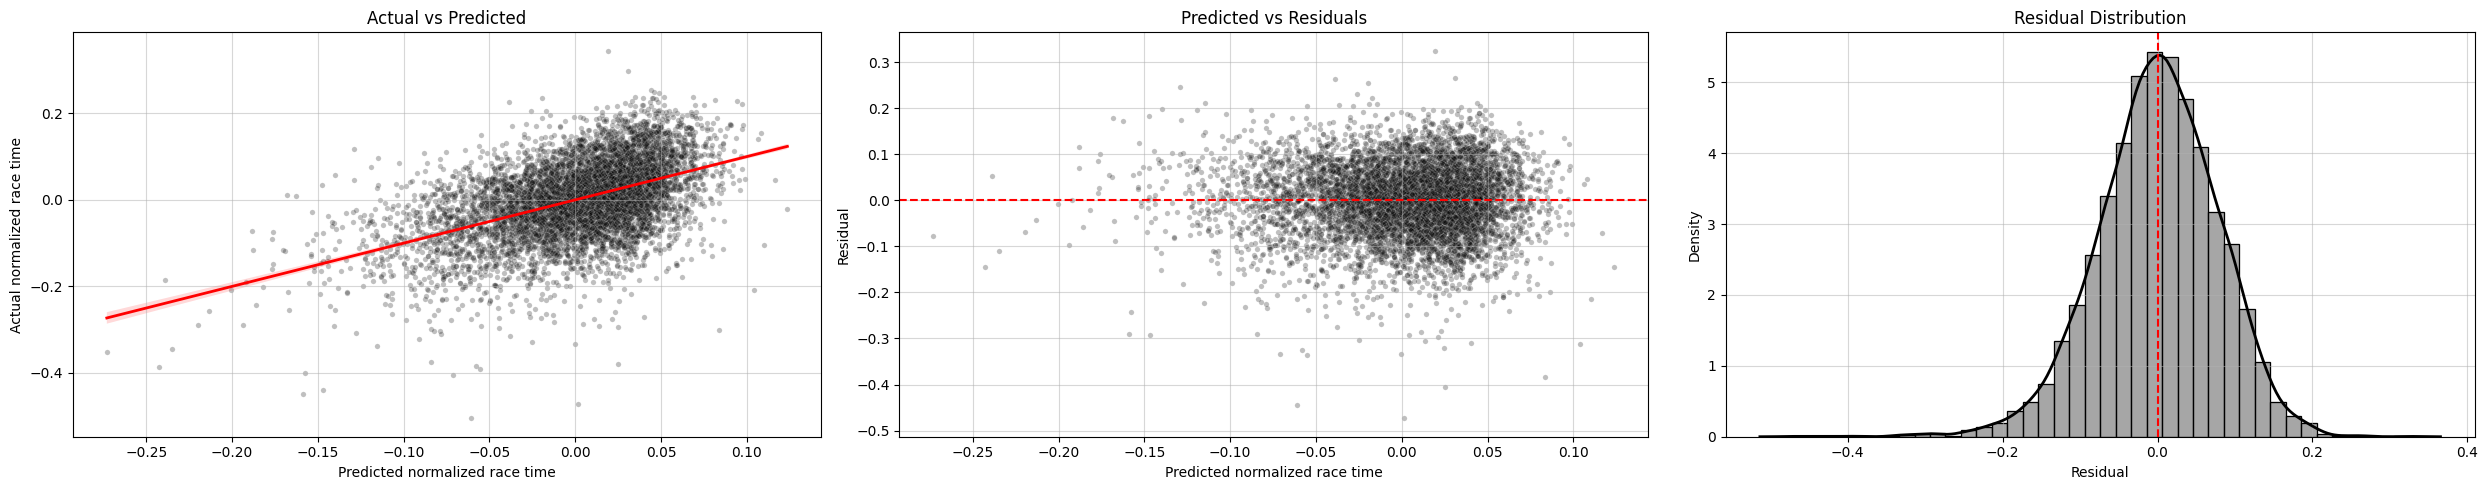

In [84]:
# Full pacing model diagnostics
fig, ax = plt.subplots(1, 3, figsize = (25, 5))

# Actual vs predicted
sns.scatterplot(
    data = df_pacing_model, x = "runner_race_time_normalized_pred", y = "runner_race_time_normalized",
    color = "black", s = 15, alpha = 0.25,
    ax = ax[0],
)
sns.regplot(
    data = df_pacing_model, x = "runner_race_time_normalized_pred", y = "runner_race_time_normalized",
    scatter = False, line_kws = {"color": "red", "linewidth": 2},
    ax = ax[0],
)

ax[0].set_title("Actual vs Predicted")
ax[0].set_xlabel("Predicted normalized race time")
ax[0].set_ylabel("Actual normalized race time")

# Predicted vs residuals
sns.scatterplot(
    data = df_pacing_model, x = "runner_race_time_normalized_pred", y = "runner_race_time_normalized_residual",
    color = "black", s = 15, alpha = 0.25,
    ax = ax[1],
)
ax[1].axhline(0, color = "red", linestyle = "--")
ax[1].set_title("Predicted vs Residuals")
ax[1].set_xlabel("Predicted normalized race time")
ax[1].set_ylabel("Residual")

# Residual distribution
sns.histplot(
    data = df_pacing_model, x = "runner_race_time_normalized_residual",
    bins = 40, stat = "density", color = "grey", edgecolor = "black", alpha = 0.7,
    ax = ax[2],
)
sns.kdeplot(
    data = df_pacing_model, x = "runner_race_time_normalized_residual",
    color = "black", linewidth = 2,
    ax = ax[2],
)
ax[2].axvline(0, color = "red", linestyle = "--")
ax[2].set_title("Residual Distribution")
ax[2].set_xlabel("Residual")

for i in [0, 1, 2]:
    ax[i].grid(alpha = 0.5)

plt.tight_layout()
plt.show()

Interpretation of Final interpretable pacing model:
- More aggressive early pacing is associated with worse normalized race performance.
- More uneven pacing is associated with worse normalized race performance.
- Stronger late-race pacing is associated with better normalized race performance.
- Late strength still matters even after accounting for early aggressiveness.

Summary: Do not start too aggressively, keep the race stable, and preserve enough strength for the late race.
- start control - Did the runner spend too much too soon?
- late-race strength - Did the runner still have enough left later in the race?
- pacing stability 

Notes:
- After accounting for early aggressiveness, late strength, and pacing variability, the single worst phase-to-phase drop does not add meaningful additional information.
- Early aggressiveness and late strength are related, but late strength also reflects other things:
    - Example: not pushing too hard in the middle.
    - Late strength remains important: the result is not explained only by the start.
    - Successful pacing is not just about avoiding a fast opening, but also about maintaining control through the middle of the race and arriving late with enough capacity to continue moving well.